File to view plots and mess around with interesting results without having to run code I don't care about for this purpose.


In [193]:
%load_ext autoreload
%autoreload 2

import sys
import os

# Get the directory where you are currently working
current_path = os.getcwd()

# Join it with '..' to go up one level to the main folder
parent_path = os.path.abspath(os.path.join(current_path, '..'))

# Add it to sys.path
if parent_path not in sys.path:
    sys.path.insert(0, parent_path)

import numpy as np
import scipy as sp
from conversions import cm_to_m, erg_to_joule
from rr_escape import get_escape_diagnostics, examine_atmosphere_for_rr_escape
from atmospheres.atmosphere_setting import Atmosphere, wind_microphysics
from bulk_param_examination import make_simple_atmosphere, sweep_parameter
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.colors as colors
import matplotlib.patches as patches
import matplotlib.ticker as ticker
from stellar_cradle import get_L_x, solar_mass, mass_to_luminosity, get_F, get_escape_fluxes
import math







The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [181]:
### Cell with much used parameters are values ###

M_earth = 5.9722 * 10**24               #[kg]        mass of the earth
au = 149597870700 #[m] distance from the sun to the earth
F_xuv_earth = 0.2198576545 #[W/m^2] solar flux at the earth 
solar_mass = 1.989 * 10**30 #[kg] mass of the sun

species_microphysics = {
    #NB, nu_0, mu_wind, mu_plus_wind are for the singly ionised and fully dissociated equivalents!!!!! mu_photo and epsilon xuv is for not dissociated.
    'H2': {'nu_0': 3.288467085473 * 10**15, 'mu_wind': 0.5, 'mu_plus_wind': 1, 'mu_photo': 2, 'epsilon_xuv': wind_microphysics['H2']['epsilon_xuv']},
    'H2O': {'nu_0': 4.835981008048 * 10**15 , 'mu_wind': 3, 'mu_plus_wind': 6, 'mu_photo': 18, "epsilon_xuv": wind_microphysics['H2O']['epsilon_xuv']},
    'CO2' : {'nu_0' : 3.3368 * 10**15, 'mu_wind': 7.2, 'mu_plus_wind': 14.4, 'mu_photo': (12+(16*2)), "epsilon_xuv": wind_microphysics['CO2']['epsilon_xuv']}, 
    'N2' : {'nu_0' : 3.7721 * 10**15, 'mu_wind': 7, 'mu_plus_wind': 14, 'mu_photo': 14*2, "epsilon_xuv": wind_microphysics['N2']['epsilon_xuv']},
    }

# Define the different distinct host star cases to populate the subplots
stellar_cases = [
    {'M_star': 0.7,  'age': 20.0 * 10**6, 'label': 'Young K-Dwarf (0.7 M$_\odot$, 20 Myr)'},
    {'M_star': 0.7,  'age': 1.0 * 10**9, 'label': 'Older K-Dwarf (0.7 M$_\odot$, 1 Gyr)'},
    {'M_star': 1.0,  'age': 20.0 * 10**6, 'label': 'Young G-Dwarf (1.0 M$_\odot$, 20 Myr)'},
    {'M_star': 1.0,  'age': 1.0 * 10**9, 'label': 'Older G-Dwarf (1.0 M$_\odot$, 1 Gyr)'},
    {'M_star': 1.20,  'age': 20.0 * 10**6, 'label': 'Young F-Dwarf (1.20 M$_\odot$, 20 Myr)'},
    {'M_star': 1.20,  'age': 1.0 * 10**9, 'label': 'Older F-Dwarf (1.20 M$_\odot$, 1 Gyr)'}
]



<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:19: SyntaxWarning: invalid escape sequence '\o'
<>:20: SyntaxWarning: invalid escape sequence '\o'
<>:21: SyntaxWarning: invalid escape sequence '\o'
<>:22: SyntaxWarning: invalid escape sequence '\o'
<>:23: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\2361940804.py:18: SyntaxWarning: invalid escape sequence '\o'
  {'M_star': 0.7,  'age': 20.0 * 10**6, 'label': 'Young K-Dwarf (0.7 M$_\odot$, 20 Myr)'},
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\2361940804.py:19: SyntaxWarning: invalid escape sequence '\o'
  {'M_star': 0.7,  'age': 1.0 * 10**9, 'label': 'Older K-Dwarf (0.7 M$_\o

In [112]:
### Convergence test ###

resolutions = np.linspace(100, 10000, 100).astype(int)
convergence_data = {}
for species in species_microphysics.keys(): #for each species
    atms_varied_resolution = np.array([make_simple_atmosphere( 
        M_p =  8.41 * 5.9722 * 10**24,               #[kg] 
        F_xuv        = 10**2.93 * erg_to_joule * cm_to_m**(-2)  ,              #[kg s^-3]    
        R_p          = 2.73 * 6.371 * 10**6  ,          #[m]         planetary radius. 2 times earth radius
        P_0          = 2000   ,                      #[Pa]        pressure at the optical photosphere
        T_eq         = 567 ,                        #[K]         equilibrium temperature of the planet
        dominant_species=species,
        mu_photo=species_microphysics[species]['mu_photo'],
        resolution=res) for res in resolutions])
    
    # Process through your diagnostics framework
    M_dot_stitched, rr_mask, M_dot_rr, M_dot_el, _ = sweep_parameter(atms_varied_resolution)
    
    # Store arrays as numpy arrays inside the tracking dictionary
    convergence_data[species] = {
        'stitched': np.array(M_dot_stitched),
        'rr': np.array(M_dot_rr),
        'el': np.array(M_dot_el)
    }

<>:63: SyntaxWarning: invalid escape sequence '\g'
<>:63: SyntaxWarning: invalid escape sequence '\g'
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\2924884347.py:63: SyntaxWarning: invalid escape sequence '\g'
  label=f'Converged Area ($\geq$ {min_res_needed})')



--- QUANTITATIVE CONVERGENCE ASSESSMENT (1.5% THRESHOLD) ---
Species: H2     | Max N bounded by: Energy-Limited (EL)          | Stabilizes at N = 500 (Diff: 0.96%)
Species: H2O    | Max N bounded by: Radiation-Recombination (RR) | Stabilizes at N = 1800 (Diff: 0.92%)
Species: CO2    | Max N bounded by: Radiation-Recombination (RR) | Stabilizes at N = 4200 (Diff: 1.30%)
Species: N2     | Max N bounded by: Radiation-Recombination (RR) | Stabilizes at N = 3900 (Diff: 1.28%)
----------------------------------------------------------


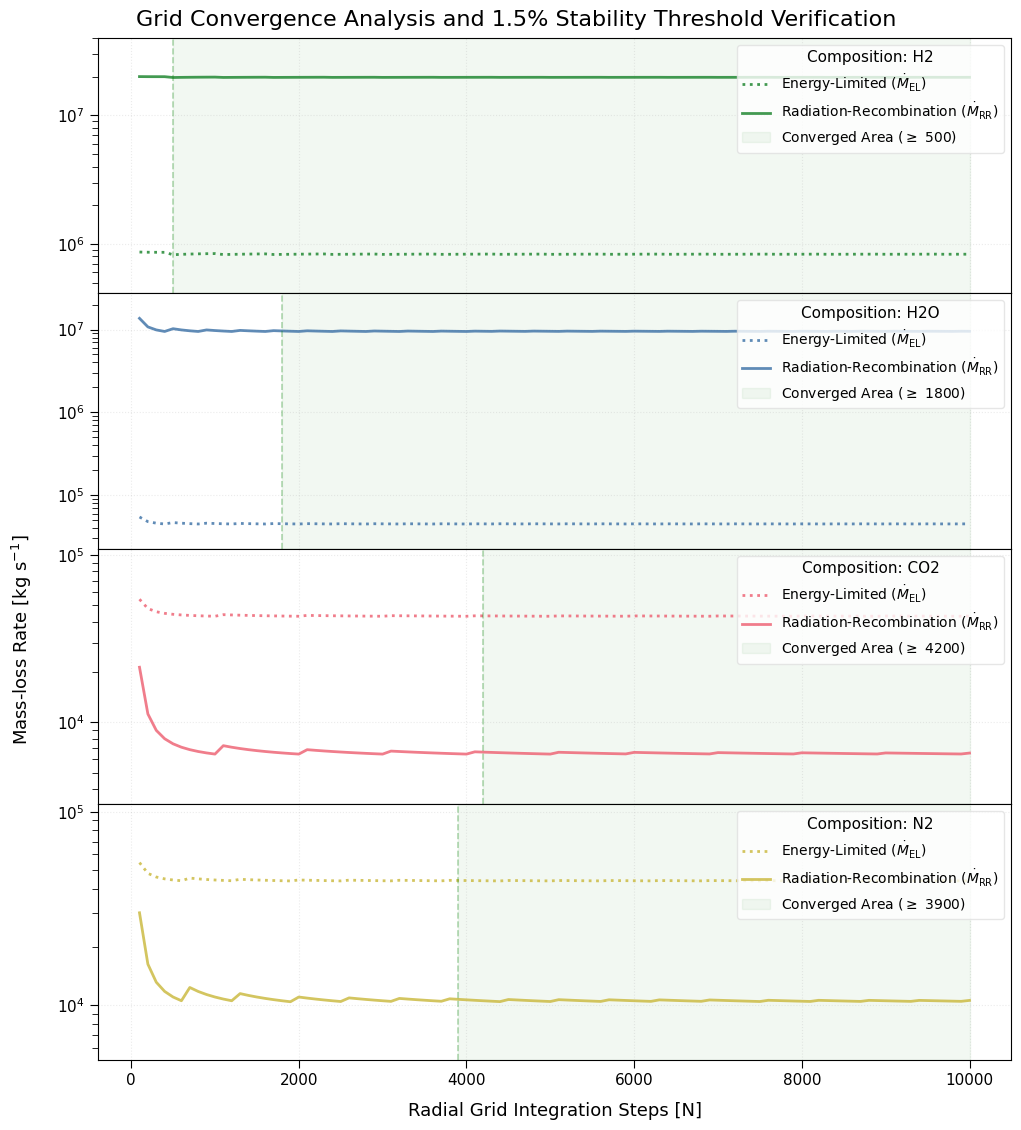

In [231]:
# 2. Render Convergence Graphic with Quantitative 1.5% Assessment
keys = list(convergence_data.keys())
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']

# Initialize figure array grid
fig, axes = plt.subplots(len(keys), 1, figsize=(11, 3.5 * len(keys)), sharex=True)

# Main Title configured without bold text weights
fig.suptitle('Grid Convergence Analysis and 1.5% Stability Threshold Verification', fontsize=16, y=0.95)

if len(keys) == 1:
    axes = [axes]

print("\n--- QUANTITATIVE CONVERGENCE ASSESSMENT (1.5% THRESHOLD) ---")

for i, species in enumerate(keys):
    ax = axes[i]
    data = convergence_data[species]
    
    # --- FIXED: independent COMPONENT CONVERGENCE CHECK ---
    # Extract baseline final values from the highest resolution cap (last elements)
    final_el = data['el'][-1]
    final_rr = data['rr'][-1]
    
    # Absolute relative difference calculation arrays
    diffs_el = np.abs((data['el'] - final_el) / final_el)
    diffs_rr = np.abs((data['rr'] - final_rr) / final_rr)
    
    # --- FOR ENERGY-LIMITED ---
    stable_idx_el = len(resolutions) - 1
    while stable_idx_el >= 0 and diffs_el[stable_idx_el] <= 0.015:
        stable_idx_el -= 1
    stable_idx_el += 1
    res_needed_el = resolutions[stable_idx_el]
    
    # --- FOR RADIATION-RECOMBINATION ---
    stable_idx_rr = len(resolutions) - 1
    while stable_idx_rr >= 0 and diffs_rr[stable_idx_rr] <= 0.015:
        stable_idx_rr -= 1
    stable_idx_rr += 1
    res_needed_rr = resolutions[stable_idx_rr]
    
    # --- HIGHEST LIMIT EXTRACTION INTERSECTION ---
    if res_needed_el >= res_needed_rr:
        min_res_needed = res_needed_el
        limiting_regime = "Energy-Limited (EL)"
        final_diff_pct = diffs_el[stable_idx_el] * 100
    else:
        min_res_needed = res_needed_rr
        limiting_regime = "Radiation-Recombination (RR)"
        final_diff_pct = diffs_rr[stable_idx_rr] * 100
        
    print(f"Species: {species:<6} | Max N bounded by: {limiting_regime:<28} | Stabilizes at N = {min_res_needed} (Diff: {final_diff_pct:.2f}%)")
    
    # --- PLOTTING DATA LINES ---
    ax.plot(resolutions, data['el'], linestyle=':', color=colours[i], alpha=0.85, lw=2.0, 
            label=r'Energy-Limited ($\dot{M}_{\mathrm{EL}}$)')
    ax.plot(resolutions, data['rr'], linestyle='-', color=colours[i], alpha=0.85, lw=2.0, 
            label=r'Radiation-Recombination ($\dot{M}_{\mathrm{RR}}$)')
        
    # Shading reflects the maximum required resolution computed dynamically above
    ax.axvspan(min_res_needed, resolutions.max(), color='green', alpha=0.05, 
               label=f'Converged Area ($\geq$ {min_res_needed})')
    
    ax.axvline(min_res_needed, color='green', linestyle='--', alpha=0.3, lw=1.2)

    # Subplot Structural Formatting Setup
    ax.grid(True, alpha=0.25, linestyle=':')
    ax.set_yscale('log')
    
    all_vals = np.concatenate([data['el'], data['rr']])
    ax.set_ylim(all_vals.min() * 0.5, all_vals.max() * 2.0)
    
    ax.tick_params(axis='both', which='major', labelsize=11, length=6)
    ax.tick_params(axis='both', which='minor', labelsize=9, length=4)
    
    # Individual Subplot Legend Blocks
    ax.legend(loc='upper right', fontsize=10, frameon=True, facecolor='white', 
              edgecolor='#e0e0e0', title=f'Composition: {species}', title_fontsize=11)

# Configure the unified global labels on the main figure canvas
axes[-1].set_xlabel('Radial Grid Integration Steps [N]', fontsize=13, labelpad=10)
fig.supylabel(r'Mass-loss Rate [$\mathrm{kg\ s}^{-1}$]', fontsize=13, x=0.04)

print("----------------------------------------------------------")
plt.subplots_adjust(hspace=0, bottom=0.2, top=0.93, left=0.12, right=0.95)
plt.savefig('Keepers/convergence_analysis.png', dpi=300)
plt.show()

In [ ]:
### Need to plot whether the escape rate is rr_limited or not, but will run it only over planetary masses. Assuming GJ1214b like planet ###

Mass_array = np.linspace(0.9, 16.6, 100) * M_earth

atmospheres_swept_varied_mass_MR = {}
for species in species_microphysics.keys(): #for each species
    atms_varied_mass_MR = np.array([make_simple_atmosphere( #make at atmosphere where only the mass is varied, but the radius is determined by an MR relation
        M_p=m,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=567,
        dominant_species=species,
        resolution=6000,
        determine_radius=True) for m in Mass_array])

    #now we have an array of atmospheres with different masses, we can sweep through them and get the mass loss rates and check if it is rr_limited
    M_dot_stitched, rr_mask, M_dot_rr, M_dot_el, transonic_mask = sweep_parameter(atms_varied_mass_MR)
    atmospheres_swept_varied_mass_MR[species] = (M_dot_stitched, rr_mask, M_dot_rr, M_dot_el, transonic_mask)



<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:58: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\d'
<>:21: SyntaxWarning: invalid escape sequence '\d'
<>:43: SyntaxWarning: invalid escape sequence '\d'
<>:58: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\4110336271.py:18: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(masses, M_dot_el, linestyle=':', color=colours[i], alpha=0.85, lw=2.5, label='Pure Energy-Limited ($\dot{M}_{EL}$)')
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\4110336271.py:21: SyntaxWarning: invalid escape sequence '\d'
  ax.plot(masses, M_dot_rr, linestyle='solid', color=colours[i], alpha=0.85, lw=2.5, label='Pure Rad-Recomb ($\dot{M}_{RR}$)')
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\4110336271.py:43: SyntaxWarning: invalid escape sequence '\d'
  

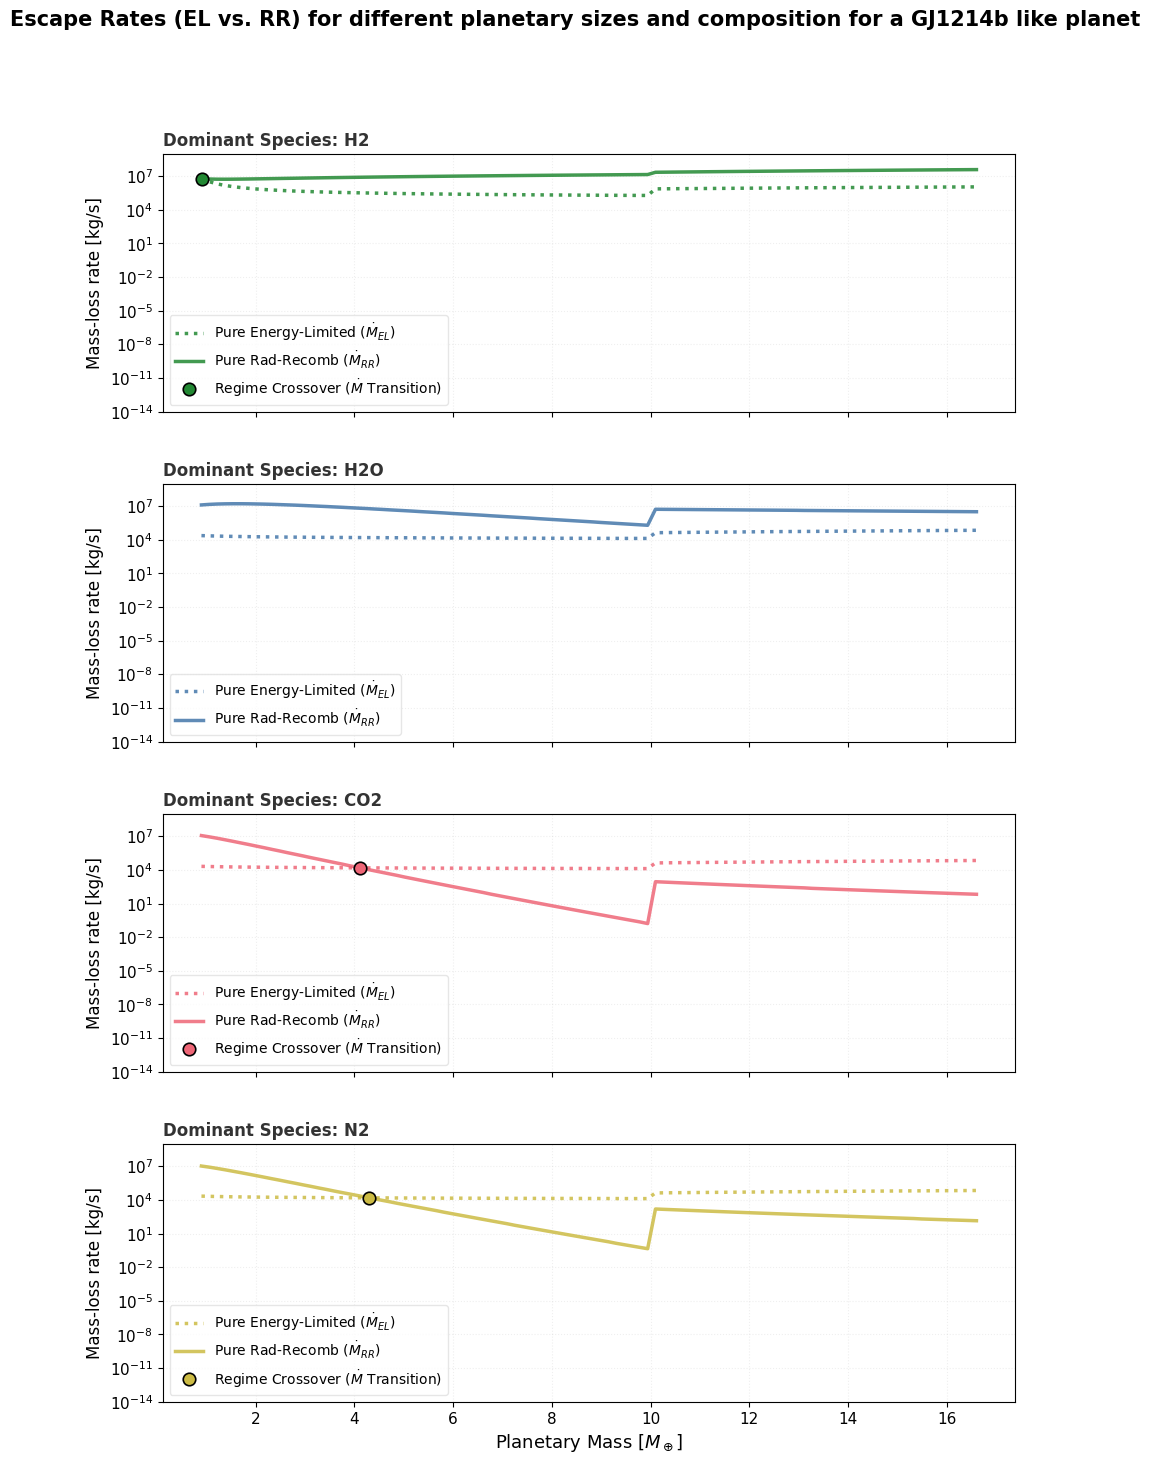

In [ ]:
keys = list(atmospheres_swept_varied_mass_MR.keys())
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44']
# Create a multi-panel figure (one row per species)
fig, axes = plt.subplots(len(keys), 1, figsize=(11, 4 * len(keys)), sharex=True)
fig.suptitle('Escape Rates (EL vs. RR) for different planetary sizes and composition for a GJ1214b like planet', fontsize=15, y=0.97, weight='bold')

masses = Mass_array / M_earth

# Ensure axes is always iterable even if only 1 species is passed
if len(keys) == 1:
    axes = [axes]

for i, species in enumerate(keys):
    ax = axes[i]
    
    # Unpack variables 
    _, _, M_dot_rr, M_dot_el, _ = atmospheres_swept_varied_mass_MR[species]
    
    # 1. Plot pure Energy-Limited curve (Dotted ':')
    ax.plot(masses, M_dot_el, linestyle=':', color=colours[i], alpha=0.85, lw=2.5, label='Pure Energy-Limited ($\dot{M}_{EL}$)')
    
    # 2. Plot pure Radiation-Recombination curve (Solid)
    ax.plot(masses, M_dot_rr, linestyle='solid', color=colours[i], alpha=0.85, lw=2.5, label='Pure Rad-Recomb ($\dot{M}_{RR}$)')
    
    # 3. Find where EL and RR cross over
    idx_cross = np.where(np.diff(np.sign(M_dot_el - M_dot_rr)))[0]
    
    for idx in idx_cross:
        m1, m2 = masses[idx], masses[idx+1]
        y_el1, y_el2 = M_dot_el[idx], M_dot_el[idx+1]
        y_rr1, y_rr2 = M_dot_rr[idx], M_dot_rr[idx+1]
        
        # Log-space interpolation for clean visual centering
        denom = (np.log10(y_el2) - np.log10(y_el1)) - (np.log10(y_rr2) - np.log10(y_rr1))
        if denom != 0:
            fraction = (np.log10(y_rr1) - np.log10(y_el1)) / denom
            cross_mass = m1 + fraction * (m2 - m1)
            cross_val = 10**(np.log10(y_el1) + fraction * (np.log10(y_el2) - np.log10(y_el1)))
        else:
            cross_mass = (m1 + m2) / 2.0
            cross_val = (y_el1 + y_el2) / 2.0
            
        ax.plot(cross_mass, cross_val, marker='o', markersize=9, 
                markerfacecolor=colours[i], markeredgecolor='black', markeredgewidth=1.2, 
                linestyle='none', zorder=4, label='Regime Crossover ($\dot{M}$ Transition)')

    # Subplot Individual Customization
    ax.set_title(f'Dominant Species: {species}', fontsize=12, weight='bold', loc='left', color='#333333')
    ax.grid(True, alpha=0.2, linestyle=':')
    ax.set_yscale('log')
    ax.set_ylim(10**(-14), 10**9)
    ax.set_ylabel('Mass-loss rate [kg/s]', fontsize=12)
    ax.tick_params(axis='both', which='major', labelsize=11)
    ax.tick_params(axis='both', which='minor', labelsize=9)
    
    # Unique legend per subplot matching its specific color assignment
    ax.legend(loc='lower left', fontsize=10, frameon=True, facecolor='white', edgecolor='#e0e0e0')

# Global X-axis label assigned only to the bottom-most plot panel
axes[-1].set_xlabel('Planetary Mass [$M_\oplus$]', fontsize=13)

plt.subplots_adjust(hspace=0.28, bottom=0.10)
plt.show()

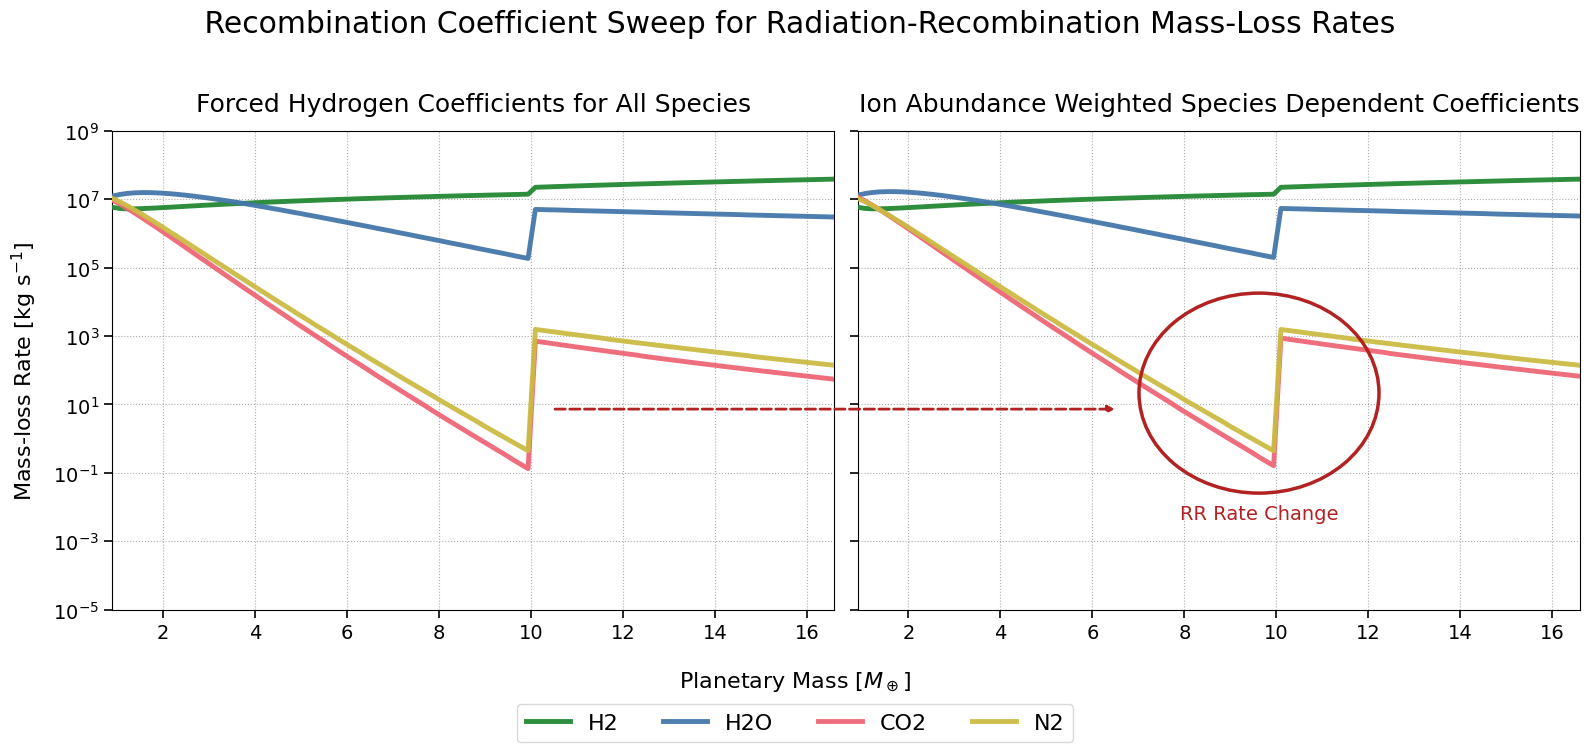

In [166]:
# 1. Initialize two separate dictionaries to store the sweeping results
results_H_coeff = {}
results_true_coeff = {}

for species in species_microphysics.keys(): 
    # --- RUN 1: FORCING HYDROGEN RECOMBINATION COEFFICIENTS ---
    atms_H_coeff = [make_simple_atmosphere( 
        M_p=m,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=wind_microphysics[species]['nu_0'],
        mu_wind=wind_microphysics[species]['mu_wind'],
        mu_plus_wind=wind_microphysics[species]['mu_plus_wind'],
        rr_coeff=wind_microphysics['H2']['rr_coeff'], 
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        dominant_species=species,
        resolution=10000,
        determine_radius=True) for m in Mass_array]

    _, _, M_dot_rr_H, _, _ = sweep_parameter(atms_H_coeff)
    results_H_coeff[species] = np.array(M_dot_rr_H)

    # --- RUN 2: USING TRUE SPECIES RECOMBINATION COEFFICIENTS ---
    atms_true_coeff = [make_simple_atmosphere( 
        M_p=m,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=wind_microphysics[species]['nu_0'],
        mu_wind=wind_microphysics[species]['mu_wind'],
        mu_plus_wind=wind_microphysics[species]['mu_plus_wind'],
        rr_coeff=wind_microphysics[species]['rr_coeff'], 
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        dominant_species=species,
        resolution=10000,
        determine_radius=True) for m in Mass_array]

    _, _, M_dot_rr_T, _, _ = sweep_parameter(atms_true_coeff)
    results_true_coeff[species] = np.array(M_dot_rr_T)


# --- 2. HIGH-READABILITY THESIS PLOTTING ROUTINE ---
keys = list(species_microphysics.keys())
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44', '#9933A5'] 

# Subplots sharing the Y-axis scale to guarantee immediate baseline visual comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharey=True)
fig.suptitle(r' Recombination Coefficient Sweep for Radiation-Recombination Mass-Loss Rates', 
             fontsize=21.5, y=0.95)
masses = Mass_array / M_earth

axes = [ax1, ax2]
datasets = [results_H_coeff, results_true_coeff]
titles = [r"Forced Hydrogen Coefficients for All Species", 
          r"Ion Abundance Weighted Species Dependent Coefficients"]

# Plot both subplots dynamically
for ax, data_dict, title in zip(axes, datasets, titles):
    ax.set_title(title, fontsize=18, pad=14, loc='center')
    
    for i, species in enumerate(keys):
        pure_rr_mass_loss = data_dict[species]
        
        # Consistent line weights, distinct coloring scheme
        ax.plot(masses, pure_rr_mass_loss, linestyle='solid', color=colours[i], 
                label=rf'{species}', lw=3.5, alpha=0.95, zorder=3)

    # Format the individual axes elements
    ax.grid(True, alpha=0.6, linestyle=':', color='#777777', zorder=1)
    
   
    
    # Scale tick marks for publication size reduction safety
    ax.tick_params(axis='both', which='major', labelsize=14, length=6, width=1.2)
    ax.tick_params(axis='both', which='minor', labelsize=12, length=4, width=0.8)
    ax.set_xlim(masses[0], masses[-1])

fig.text(0.5, 0.11, r'Planetary Mass [$M_\oplus$]', fontsize=16, ha='center', va='center')

# Set the primary shared y-axis properties only on the left-most axis
ax1.set_ylabel(r'Mass-loss Rate [$\mathrm{kg\ s}^{-1}$]', fontsize=16, labelpad=10)
ax1.set_ylim(10**(-5), 10**9)
ax1.set_yscale('log')

# --- CREATING A UNIQUE SHARED GLOBAL LEGEND ---
# Extract lines and labels from the first axis to build a unified legend bar at the bottom
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles=handles, labels=labels, loc='lower center', bbox_to_anchor=(0.5, 0.02),
           ncol=len(keys), fontsize=16, frameon=True, facecolor='white', edgecolor='#d0d0d0')

# Padding layout adjustment to securely reserve empty space at the bottom for the shared legend
plt.tight_layout(rect=[0, 0.14, 1, 0.92])

# Define an ellipse using Figure coordinates (independent of the log-scale warp)
# xy=(center_x, center_y), width, height
highlight_circle = patches.Ellipse(
    xy=(0.79, 0.47),        # 0.5 is horizontally centered, 0.6 is slightly above middle
    width=0.15,           # Width as a fraction of the total figure width
    height=0.25,          # Height as a fraction of the total figure height
    angle=180,             # Tilt angle in degrees if you want it diagonal
    edgecolor='firebrick',# High-contrast color for thesis readability
    facecolor='none',     # Transparent inside
    linewidth=2.5,        # Sharp line weight
    linestyle='-',        # Solid line
    transform=fig.transFigure, # Dictates that we are using global Figure coordinates
    zorder=5              # Ensures it sits strictly on top of lines and grids
)

# Add the patch directly to the figure canvas
fig.patches.append(highlight_circle)
fig.text(0.79, 0.32, r'RR Rate Change', fontsize=14, ha='center', va='center', color='firebrick')

pointer_line = patches.ConnectionPatch(
    xyA=(0.35, 0.45),       # Start point (e.g., where you might put a text label)
    xyB=(0.7, 0.45),      # End point (touching the top edge of your oblong circle)
    coordsA=fig.transFigure,
    coordsB=fig.transFigure,
    color='firebrick',
    linewidth=2,
    linestyle='--',
    arrowstyle="-|>"      # Adds a neat, professional arrowhead pointing at the region
)

fig.patches.append(pointer_line)
# plt.savefig('Keepers/Mass_sweep_MR_Comparison.png', dpi=300, bbox_inches='tight')
plt.show()



In [167]:
max_pct_diffs = {}

for key in keys:
    # Use the true species coefficient run as the baseline "ground truth"
    baseline = results_true_coeff[key]
    
    # Avoid potential division by zero if any rates are exactly 0
    with np.errstate(divide='ignore', invalid='ignore'):
        pct_diff = np.abs(results_H_coeff[key] - baseline) / baseline * 100
        # Replace NaNs or Infs with 0 if they occur at the lower boundary
        pct_diff = np.nan_to_num(pct_diff, nan=0.0, posinf=0.0)
    
    max_pct_diffs[key] = np.max(pct_diff)
    print(f"Species: {key:<6} | Maximum deviation from true value: {max_pct_diffs[key]:.2f}%")

# Find the absolute peak percentage change across the entire study
overall_max_pct = np.max(list(max_pct_diffs.values()))
print(f"\nOverall maximum impact of switching coefficients: {overall_max_pct:.2f}%")

Species: H2     | Maximum deviation from true value: 0.00%
Species: H2O    | Maximum deviation from true value: 6.38%
Species: CO2    | Maximum deviation from true value: 18.04%
Species: N2     | Maximum deviation from true value: 0.39%

Overall maximum impact of switching coefficients: 18.04%


In [168]:
print("--- AVERAGE IMPACT ANALYSIS (ORDERS OF MAGNITUDE SHIFT) ---")
mean_log_diffs = {}

for key in keys:
    # Avoid log10(0) issues by filtering out or handling extremely small unphysical numbers
    log_H = np.log10(np.clip(results_H_coeff[key], 10**-20, None))
    log_T = np.log10(np.clip(results_true_coeff[key], 10**-20, None))
    
    # Absolute difference in log-space represents a factor change
    log_diff = np.abs(log_H - log_T)
    
    mean_log_diffs[key] = np.mean(log_diff)
    # 10**mean_log_diffs gives the average multiplicative factor change
    factor_change = 10**mean_log_diffs[key]
    
    print(f"Species: {key:<6} | Average log10 shift: {mean_log_diffs[key]:.3f} dex (Factor of {factor_change:.2f}x)")

--- AVERAGE IMPACT ANALYSIS (ORDERS OF MAGNITUDE SHIFT) ---
Species: H2     | Average log10 shift: 0.000 dex (Factor of 1.00x)
Species: H2O    | Average log10 shift: 0.029 dex (Factor of 1.07x)
Species: CO2    | Average log10 shift: 0.086 dex (Factor of 1.22x)
Species: N2     | Average log10 shift: 0.002 dex (Factor of 1.00x)


<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:15: SyntaxWarning: invalid escape sequence '\c'
<>:16: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\o'
<>:33: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\53485112.py:14: SyntaxWarning: invalid escape sequence '\c'
  ax.scatter(MR_masses[low_mass_mask], radii[low_mass_mask], label='R = $1.02 \cdot M_{{p,\oplus}}^{0.28}$', color='#0072b2')
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\53485112.py:15: SyntaxWarning: invalid escape sequence '\c'
  ax.scatter(MR_masses[intermediate_mass_mask], radii[intermediate_mass_mask], label='R = $0.61 \cdot M_{{p,\oplus}}^{0.67}$', color='#cc79a7')
C:

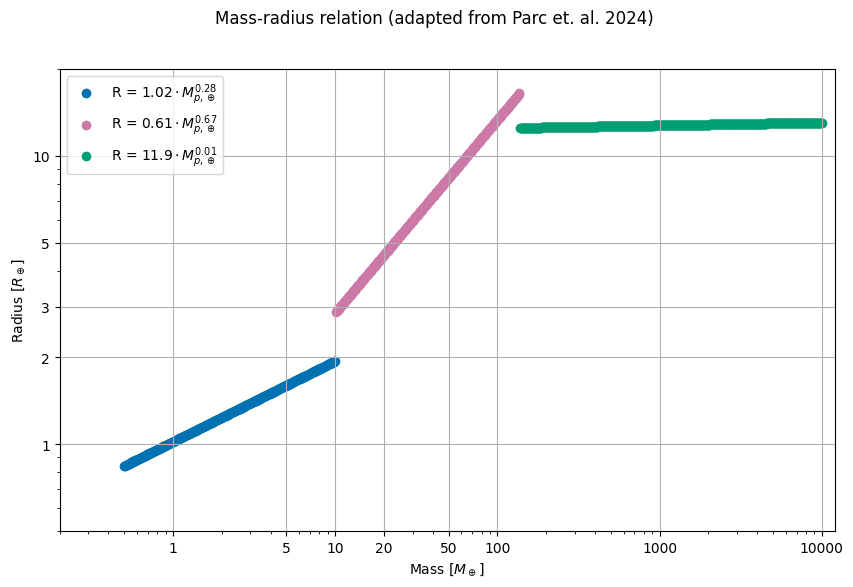

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(10,6))
fig.suptitle('Mass-radius relation (adapted from Parc et. al. 2024)')
#Setting up the masses and radii we want to plot the relation of
R_earth = 6371000 #[m] mean earth radius
MR_masses = np.logspace(-0.3, 4, 1000) #[M_earth]
radii = np.array([Atmosphere.determine_radius_from_MR_relation(m)/R_earth for m in (MR_masses * M_earth)])

#Creating the masks
low_mass_mask = MR_masses < 10 #needs to be divided by earth masses again because the comparison is in earth masses
intermediate_mass_mask =  (MR_masses >= 10) & (MR_masses < 138)
high_mass_mask = MR_masses >= 138

#plotting the masks
ax.scatter(MR_masses[low_mass_mask], radii[low_mass_mask], label='R = $1.02 \cdot M_{{p,\oplus}}^{0.28}$', color='#0072b2')
ax.scatter(MR_masses[intermediate_mass_mask], radii[intermediate_mass_mask], label='R = $0.61 \cdot M_{{p,\oplus}}^{0.67}$', color='#cc79a7')
ax.scatter(MR_masses[high_mass_mask], radii[high_mass_mask], label='R = $11.9 \cdot M_{{p,\oplus}}^{0.01}$', color='#009e73')

#Switching axes to log scales
ax.set_xscale('log')
ax.set_yscale('log')

#Defineing and forcing the exact tick marks seen in the paper by Parc et. al. 2024
x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])

y_ticks = [1, 2, 3, 5, 10]
ax.set_yticks(y_ticks, labels=[str(y) for y in y_ticks])

#Sets limits to frame the data like the paper's plot bounds
ax.set_xlim(0.2, 12000)
ax.set_ylim(0.5, 20)
ax.set_xlabel('Mass [$M_\oplus$]')
ax.set_ylabel('Radius [$R_\oplus$]')
ax.grid()
ax.legend()
#plt.savefig('Keepers/MR_relation.png', dpi=300)
plt.show()
plt.close(fig)

<>:90: SyntaxWarning: invalid escape sequence '\ '
<>:91: SyntaxWarning: invalid escape sequence '\o'
<>:95: SyntaxWarning: invalid escape sequence '\ '
<>:96: SyntaxWarning: invalid escape sequence '\o'
<>:90: SyntaxWarning: invalid escape sequence '\ '
<>:91: SyntaxWarning: invalid escape sequence '\o'
<>:95: SyntaxWarning: invalid escape sequence '\ '
<>:96: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\1708347877.py:90: SyntaxWarning: invalid escape sequence '\ '
  f'• Radii: $1.0 - 1.7\ R_\oplus$\n'
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\1708347877.py:91: SyntaxWarning: invalid escape sequence '\o'
  f'• Masses: {mass_at_1_0:.1f} - {mass_at_1_7:.1f} $M_\oplus$')
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\1708347877.py:95: SyntaxWarning: invalid escape sequence '\ '
  f'• Radii: $1.7 - 4.0\ R_\oplus$\n'
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\1708347877.py:96: SyntaxWarning: invalid escape sequence '\o'
  f

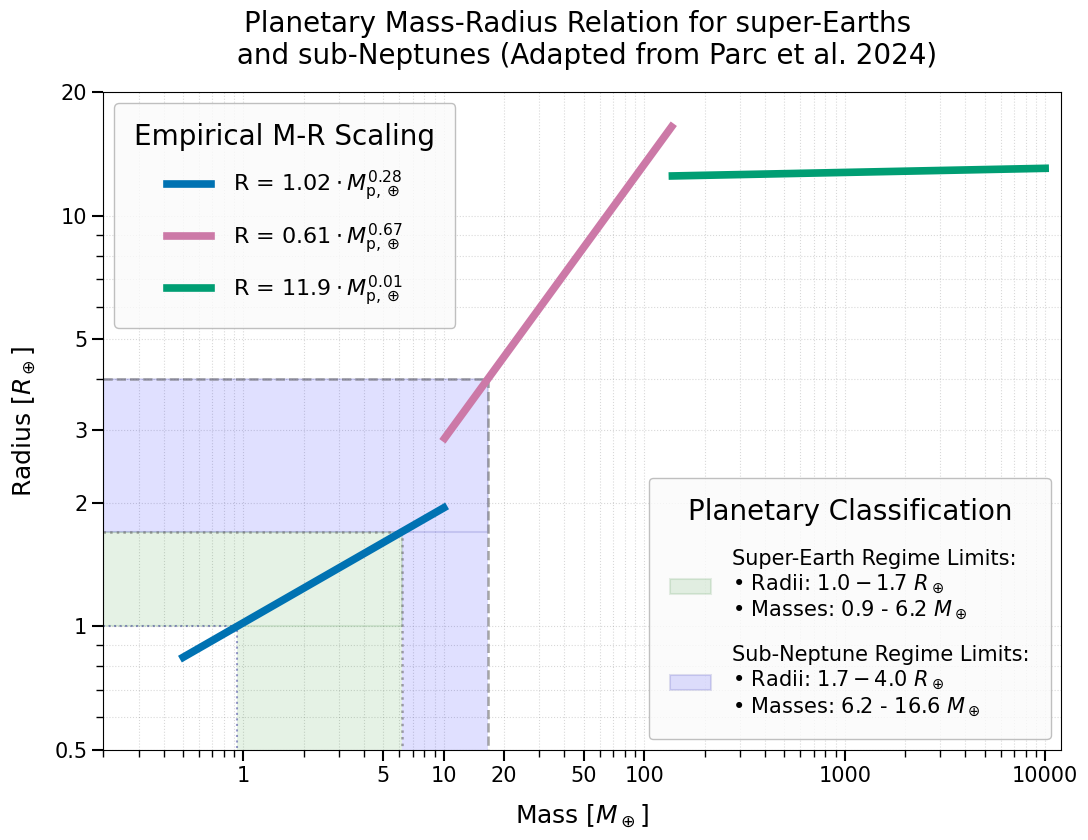

In [206]:
fig, ax = plt.subplots(1, 1, figsize=(11, 8.5)) # Slightly expanded width to balance large boxes

# Setting up the masses and radii we want to plot the relation of
R_earth = 6371000 #[m] mean earth radius
MR_masses = np.logspace(-0.3, 4, 1000) #[M_earth]
radii = np.array([Atmosphere.determine_radius_from_MR_relation(m)/R_earth for m in (MR_masses * M_earth)])

# --- NUMERICAL EXTRACTION OF BOUNDARY MASSES ---
mass_at_1_0 = np.interp(1.0, radii, MR_masses)
mass_at_1_7 = np.interp(1.7, radii, MR_masses)
mass_at_4_0 = np.interp(4.0, radii, MR_masses)

# Defining plot absolute limits early to construct the background bounding geometry
x_min, x_max = 0.2, 12000
y_min, y_max = 0.5, 20

# --- SHADING THE L-SHAPED SUPER-EARTH REGION ---
# FIXED: Changed 'darkgeometry' to 'darkgreen'
se_horiz_box = patches.Polygon([
    [x_min, 1.0], [mass_at_1_7, 1.0], 
    [mass_at_1_7, 1.7], [x_min, 1.7]
], closed=True, facecolor='green', alpha=0.10, edgecolor='darkgreen', linewidth=1.5, zorder=1)

se_vert_box = patches.Polygon([
    [mass_at_1_0, y_min], [mass_at_1_7, y_min], 
    [mass_at_1_7, 1.0], [mass_at_1_0, 1.0]
], closed=True, facecolor='green', alpha=0.10, edgecolor='none', zorder=1)

ax.add_patch(se_horiz_box)
ax.add_patch(se_vert_box)

# --- SHADING THE L-SHAPED SUB-NEPTUNE REGION ---
sn_horiz_box = patches.Polygon([
    [x_min, 1.7], [mass_at_4_0, 1.7], 
    [mass_at_4_0, 4.0], [x_min, 4.0]
], closed=True, facecolor='blue', alpha=0.12, edgecolor='darkblue', linewidth=1.5, zorder=1)

sn_vert_box = patches.Polygon([
    [mass_at_1_7, y_min], [mass_at_4_0, y_min], 
    [mass_at_4_0, 1.7], [mass_at_1_7, 1.7]
], closed=True, facecolor='blue', alpha=0.12, edgecolor='none', zorder=1)

ax.add_patch(sn_horiz_box)
ax.add_patch(sn_vert_box)

# --- PLOTTING RELATION LINES (Thicker Line Weights) ---
low_mass_mask = MR_masses < 10 
intermediate_mass_mask = (MR_masses >= 10) & (MR_masses < 138)
high_mass_mask = MR_masses >= 138

line1, = ax.plot(MR_masses[low_mass_mask], radii[low_mass_mask], 
                 label=r'R = $1.02 \cdot M_{\mathrm{p},\oplus}^{0.28}$', color='#0072b2', lw=5.5, zorder=3)
line2, = ax.plot(MR_masses[intermediate_mass_mask], radii[intermediate_mass_mask], 
                 label=r'R = $0.61 \cdot M_{\mathrm{p},\oplus}^{0.67}$', color='#cc79a7', lw=5.5, zorder=3)
line3, = ax.plot(MR_masses[high_mass_mask], radii[high_mass_mask], 
                 label=r'R = $11.9 \cdot M_{\mathrm{p},\oplus}^{0.01}$', color='#009e73', lw=5.5, zorder=3)

# --- VISUAL BOUNDARY CORNERS ---
ax.plot([x_min, mass_at_1_0, mass_at_1_0], [1.0, 1.0, y_min], 
        color='navy', linestyle=':', alpha=0.4, lw=1.5, zorder=2)
ax.plot([x_min, mass_at_1_7, mass_at_1_7], [1.7, 1.7, y_min], 
        color='dimgray', linestyle=':', alpha=0.6, lw=1.8, zorder=2)
ax.plot([x_min, mass_at_4_0, mass_at_4_0], [4.0, 4.0, y_min], 
        color='dimgray', linestyle='--', alpha=0.6, lw=1.8, zorder=2)

# --- AXIS SCALES & BOUNDS ---
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

# --- GRAPHICS CLEANUP & TYPOGRAPHY ---
ax.set_title('Planetary Mass-Radius Relation for super-Earths \n and sub-Neptunes (Adapted from Parc et al. 2024)', fontsize=20, pad=20)
ax.set_xlabel(r'Mass [$M_\oplus$]', fontsize=18, labelpad=12)
ax.set_ylabel(r'Radius [$R_\oplus$]', fontsize=18, labelpad=12)

x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])
y_ticks = [0.5, 1, 2, 3, 5, 10, 20]
ax.set_yticks(y_ticks, labels=[str(y) for y in y_ticks])

ax.tick_params(axis='both', which='major', labelsize=15, length=8, width=1.5)
ax.tick_params(axis='both', which='minor', labelsize=13, length=5, width=1.0)

ax.grid(True, which='both', linestyle=':', alpha=0.3, color='gray', zorder=0)
ax.set_axisbelow(True)

# --- CUSTOM MULTI-LINE LEGEND TEXT GENERATION ---
se_legend_label = (f'Super-Earth Regime Limits:\n'
                   f'• Radii: $1.0 - 1.7\ R_\oplus$\n'
                   f'• Masses: {mass_at_1_0:.1f} - {mass_at_1_7:.1f} $M_\oplus$')
se_horiz_box.set_label(se_legend_label)

sn_legend_label = (f'Sub-Neptune Regime Limits:\n'
                   f'• Radii: $1.7 - 4.0\ R_\oplus$\n'
                   f'• Masses: {mass_at_1_7:.1f} - {mass_at_4_0:.1f} $M_\oplus$')
sn_horiz_box.set_label(sn_legend_label)


# =============================================================================
# OPTIMIZED: ULTRA-LARGE LEGEND BOX PLACEMENTS WITH COMPACT INTERIOR SPACING
# =============================================================================

# Legend 1: Equations (Placed in Upper Left with bumped spacing properties)
legend1 = ax.legend(handles=[line1, line2, line3], title="Empirical M-R Scaling", 
                    fontsize=16, title_fontsize=20, loc='upper left', 
                    borderpad=0.9, labelspacing=0.8, handletextpad=1.0,
                    frameon=True, facecolor='#fbfbfb', edgecolor='#b0b0b0')

# Add Legend 1 manually as a persistent artist so the next call won't overwrite it
ax.add_artist(legend1)

# Legend 2: Demographic Zones (Placed in Lower Right with matching spacing formats)
legend2 = ax.legend(handles=[se_horiz_box, sn_horiz_box], title="Planetary Classification",
                    fontsize=15, title_fontsize=20, loc='lower right', 
                    borderpad=1.0, labelspacing=1.1, handletextpad=1.0,
                    frameon=True, facecolor='#fbfbfb', edgecolor='#b0b0b0')


# =============================================================================

plt.tight_layout()
plt.savefig('Keepers/MR_relation_improved.png', dpi=300)
plt.show()
plt.close(fig)

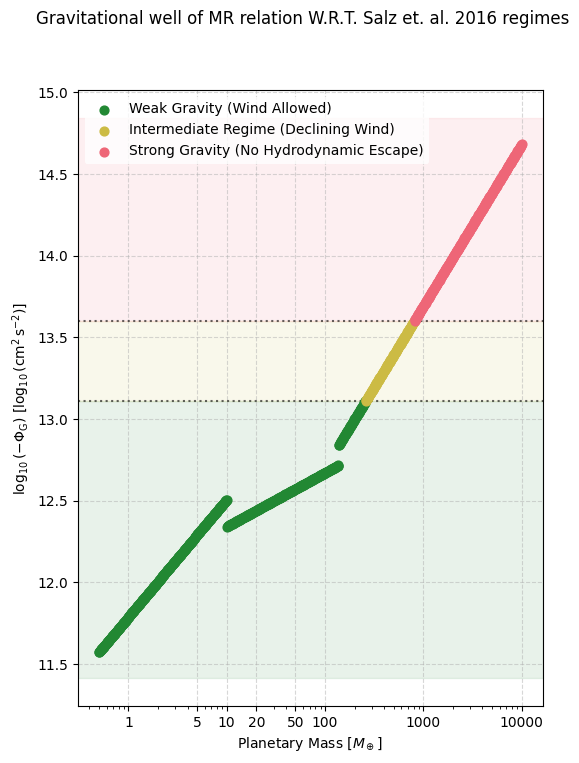

In [ ]:
### Want to see how the gravitational well changes with the MR relation ###

### compare with salz et al 2016 if can host hydrodynamic escape ###
G = sp.constants.G #[m^3 kg^-1 s^-2]

grav_pot_SI = np.array([- G * m / Atmosphere.determine_radius_from_MR_relation(m) for m in (MR_masses * M_earth)]) #[m^2 s^-2] gravitational potential at the planetary radius, where G: gravitational constant, M_p: planetary mass, R_p: planetary radius
grav_pot_cgs = grav_pot_SI * cm_to_m**(-2) #[cm^2 s^-2] gravitational potential at the planetary radius in cgs units, where grav_pot_SI: gravitational potential at the planetary radius in SI units
grav_compare = np.log10(-grav_pot_cgs) #[log10(cm^2 s^-2)] logarithm of the negative gravitational potential at the planetary radius in cgs units, where grav_pot_cgs: gravitational potential at the planetary radius in cgs units
salz_strong_grav_threshold = 13.6 #Larger than this value and gravity is too high for hydrodynamic escape. No EL and no wind for RR. REFERENCE Salz et. al. 2016
salz_weak_grav_threshold = 13.11 #Smaller than this value and the planet can host hydrodynamic wind and therefore EL and RR.

fig, ax = plt.subplots(1, 1, figsize=(6, 8))
fig.suptitle('Gravitational well of MR relation W.R.T. Salz et. al. 2016 regimes')

#Masks for the three possible regimes for the atmospheres:
weak_grav_mask = grav_compare < salz_weak_grav_threshold
strong_grav_mask = grav_compare > salz_strong_grav_threshold
intermediate_mask = (grav_compare >= salz_weak_grav_threshold) & (grav_compare <= salz_strong_grav_threshold)

ax.scatter(MR_masses[weak_grav_mask], grav_compare[weak_grav_mask], 
           color='#228833', s=40, zorder=3, label='Weak Gravity (Wind Allowed)')

ax.scatter(MR_masses[intermediate_mask], grav_compare[intermediate_mask], 
           color='#CCBB44', s=40, zorder=3, label='Intermediate Regime (Declining Wind)')

ax.scatter(MR_masses[strong_grav_mask], grav_compare[strong_grav_mask], 
           color='#EE6677', s=40, zorder=3, label='Strong Gravity (No Hydrodynamic Escape)')

#Visual Enhancements: Add Threshold Lines and Shading 
ax.axhline(salz_weak_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)
ax.axhline(salz_strong_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)

# Soft background color shading for each area
ax.axhspan(ax.get_ylim()[0], salz_weak_grav_threshold, color='#228833', alpha=0.1, zorder=1)
ax.axhspan(salz_weak_grav_threshold, salz_strong_grav_threshold, color='#CCBB44', alpha=0.1, zorder=1)
ax.axhspan(salz_strong_grav_threshold, ax.get_ylim()[1], color='#EE6677', alpha=0.1, zorder=1)

#5 Labels and Formatting
ax.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.set_xlabel(r'Planetary Mass [$M_\oplus$]')
ax.set_ylabel(r'$\log_{10}(-\Phi_\mathrm{G})$ [$\log_{10}(\mathrm{cm}^2\,\mathrm{s}^{-2})$]')
ax.semilogx()
x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])
# Place the legend in a clean spot
ax.legend(loc='best', frameon=True, shadow=False, facecolor='white', edgecolor='none')
ax.grid(True)
#plt.savefig('Keepers/GravPotential_vs_Regime_MR_relation.png', dpi=300)
plt.show()
plt.close()

<>:89: SyntaxWarning: invalid escape sequence '\ '
<>:89: SyntaxWarning: invalid escape sequence '\ '
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\3622313235.py:89: SyntaxWarning: invalid escape sequence '\ '
  f'Masses: $0.9 - 16.6\ M_\oplus$\n')


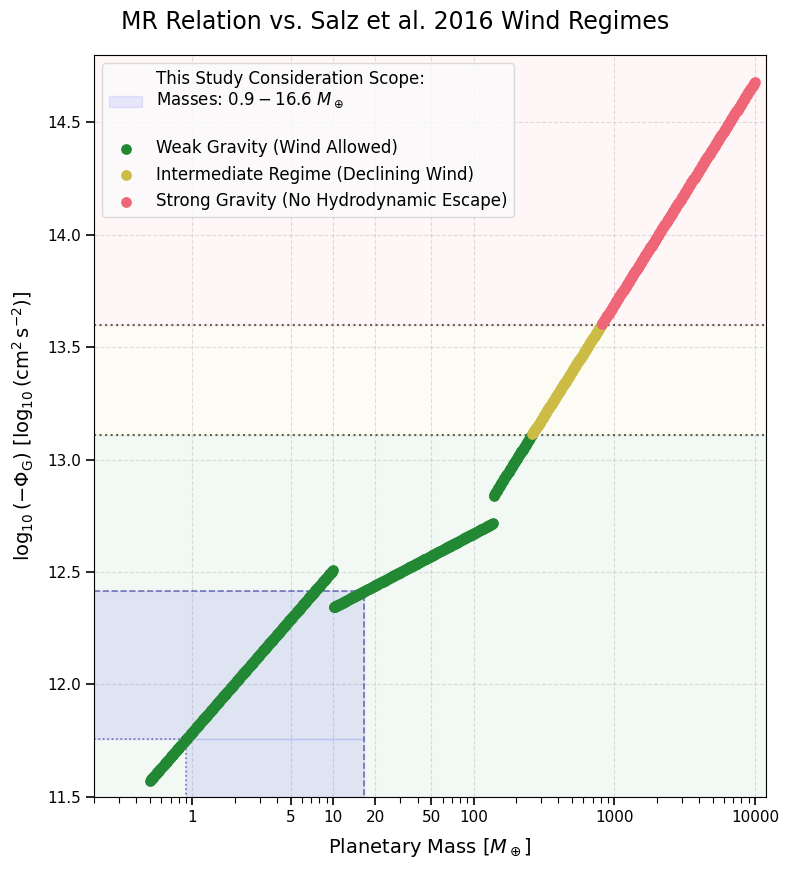

In [209]:
G = sp.constants.G #[m^3 kg^-1 s^-2]

grav_pot_SI = np.array([- G * m / Atmosphere.determine_radius_from_MR_relation(m) for m in (MR_masses * M_earth)]) #[m^2 s^-2]
grav_pot_cgs = grav_pot_SI * cm_to_m**(-2) #[cm^2 s^-2]
grav_compare = np.log10(-grav_pot_cgs) #[log10(cm^2 s^-2)]

salz_strong_grav_threshold = 13.6 
salz_weak_grav_threshold = 13.11 

# --- NUMERICAL EXTRACTION OF RELEVANT BOUNDARY VALUES ---
# Find the exact gravitational potential at your mass limits
grav_at_0_9 = np.interp(0.9, MR_masses, grav_compare)
grav_at_16_6 = np.interp(16.6, MR_masses, grav_compare)

# Establish dynamic axis plot limits early to securely align background geometries
x_min, x_max = 0.2, 12000
y_min, y_max = 11.5, 14.8

# Initialize figure with publication aspect ratio
fig, ax = plt.subplots(1, 1, figsize=(8, 9))
fig.suptitle('MR Relation vs. Salz et al. 2016 Wind Regimes', fontsize=17, y=0.96)

# --- SHADING THE L-SHAPED STUDY SCOPE REGION (0.9 to 16.6 M_earth) ---
# 1. Horizontal block extending from the left edge (x_min) to the upper mass boundary (16.6)
#    spanning vertically from the lowest potential (grav_at_0_9) up to the highest potential (grav_at_16_6)
scope_horiz_box = patches.Polygon([
    [x_min, grav_at_0_9], [16.6, grav_at_0_9], 
    [16.6, grav_at_16_6], [x_min, grav_at_16_6]
], closed=True, color='blue', alpha=0.08, zorder=1)

# 2. Vertical block extending from the bottom axis floor (y_min) up to the lower potential edge
#    spanning horizontally across the exact mass window (0.9 to 16.6 M_earth)
scope_vert_box = patches.Polygon([
    [0.9, y_min], [16.6, y_min], 
    [16.6, grav_at_0_9], [0.9, grav_at_0_9]
], closed=True, color='blue', alpha=0.08, zorder=1)

ax.add_patch(scope_horiz_box)
ax.add_patch(scope_vert_box)

# --- MASKS FOR REGIME CLASSIFICATIONS ---
weak_grav_mask = grav_compare < salz_weak_grav_threshold
strong_grav_mask = grav_compare > salz_strong_grav_threshold
intermediate_mask = (grav_compare >= salz_weak_grav_threshold) & (grav_compare <= salz_strong_grav_threshold)

# Scatter distributions
ax.scatter(MR_masses[weak_grav_mask], grav_compare[weak_grav_mask], 
           color='#228833', s=45, zorder=3, label='Weak Gravity (Wind Allowed)')

ax.scatter(MR_masses[intermediate_mask], grav_compare[intermediate_mask], 
           color='#CCBB44', s=45, zorder=3, label='Intermediate Regime (Declining Wind)')

ax.scatter(MR_masses[strong_grav_mask], grav_compare[strong_grav_mask], 
           color='#EE6677', s=45, zorder=3, label='Strong Gravity (No Hydrodynamic Escape)')

# --- VISUAL ENHANCEMENTS: LINES AND BASE SHADING ---
ax.axhline(salz_weak_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)
ax.axhline(salz_strong_grav_threshold, color='black', linestyle=':', alpha=0.6, zorder=2)

# Soft background color shading for each area behind the main focus box
ax.axhspan(y_min, salz_weak_grav_threshold, color='#228833', alpha=0.06, zorder=0)
ax.axhspan(salz_weak_grav_threshold, salz_strong_grav_threshold, color='#CCBB44', alpha=0.06, zorder=0)
ax.axhspan(salz_strong_grav_threshold, y_max, color='#EE6677', alpha=0.06, zorder=0)

# Inner dashed guide lines detailing the L-shape borders
ax.plot([x_min, 0.9, 0.9], [grav_at_0_9, grav_at_0_9, y_min], 
        color='navy', linestyle=':', alpha=0.5, lw=1.2, zorder=2)
ax.plot([x_min, 16.6, 16.6], [grav_at_16_6, grav_at_16_6, y_min], 
        color='navy', linestyle='--', alpha=0.5, lw=1.2, zorder=2)

# --- LABELS AND FORMATTING ---
ax.set_xlabel(r'Planetary Mass [$M_\oplus$]', fontsize=14, labelpad=8)
ax.set_ylabel(r'$\log_{10}(-\Phi_\mathrm{G})$ [$\log_{10}(\mathrm{cm}^2\,\mathrm{s}^{-2})$]', fontsize=14, labelpad=8)
ax.set_xscale('log')

ax.set_xlim(x_min, x_max)
ax.set_ylim(y_min, y_max)

x_ticks = [1, 5, 10, 20, 50, 100, 1000, 10000]
ax.set_xticks(x_ticks, labels=[str(x) for x in x_ticks])
ax.tick_params(axis='both', which='major', labelsize=11, length=6, width=1.2)
ax.tick_params(axis='both', which='minor', length=4, width=0.8)

ax.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# Generate specific legend tracking metadata for the consideration scope
scope_legend_label = (f'This Study Consideration Scope:\n'
                      f'Masses: $0.9 - 16.6\ M_\oplus$\n')
scope_horiz_box.set_label(scope_legend_label)

# Place the legend in a clean spot with a crisp boundary frame
ax.legend(loc='upper left', frameon=True, facecolor='#fbfbfb', edgecolor='#d3d3d3', fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('Keepers/GravPotential_vs_Regime_MR_relation.png', dpi=300)
plt.show()
plt.close()

<>:70: SyntaxWarning: invalid escape sequence '\o'
<>:70: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\581298666.py:70: SyntaxWarning: invalid escape sequence '\o'
  ax.set_xlabel(' $F_{XUV,\oplus}$', fontsize=14)


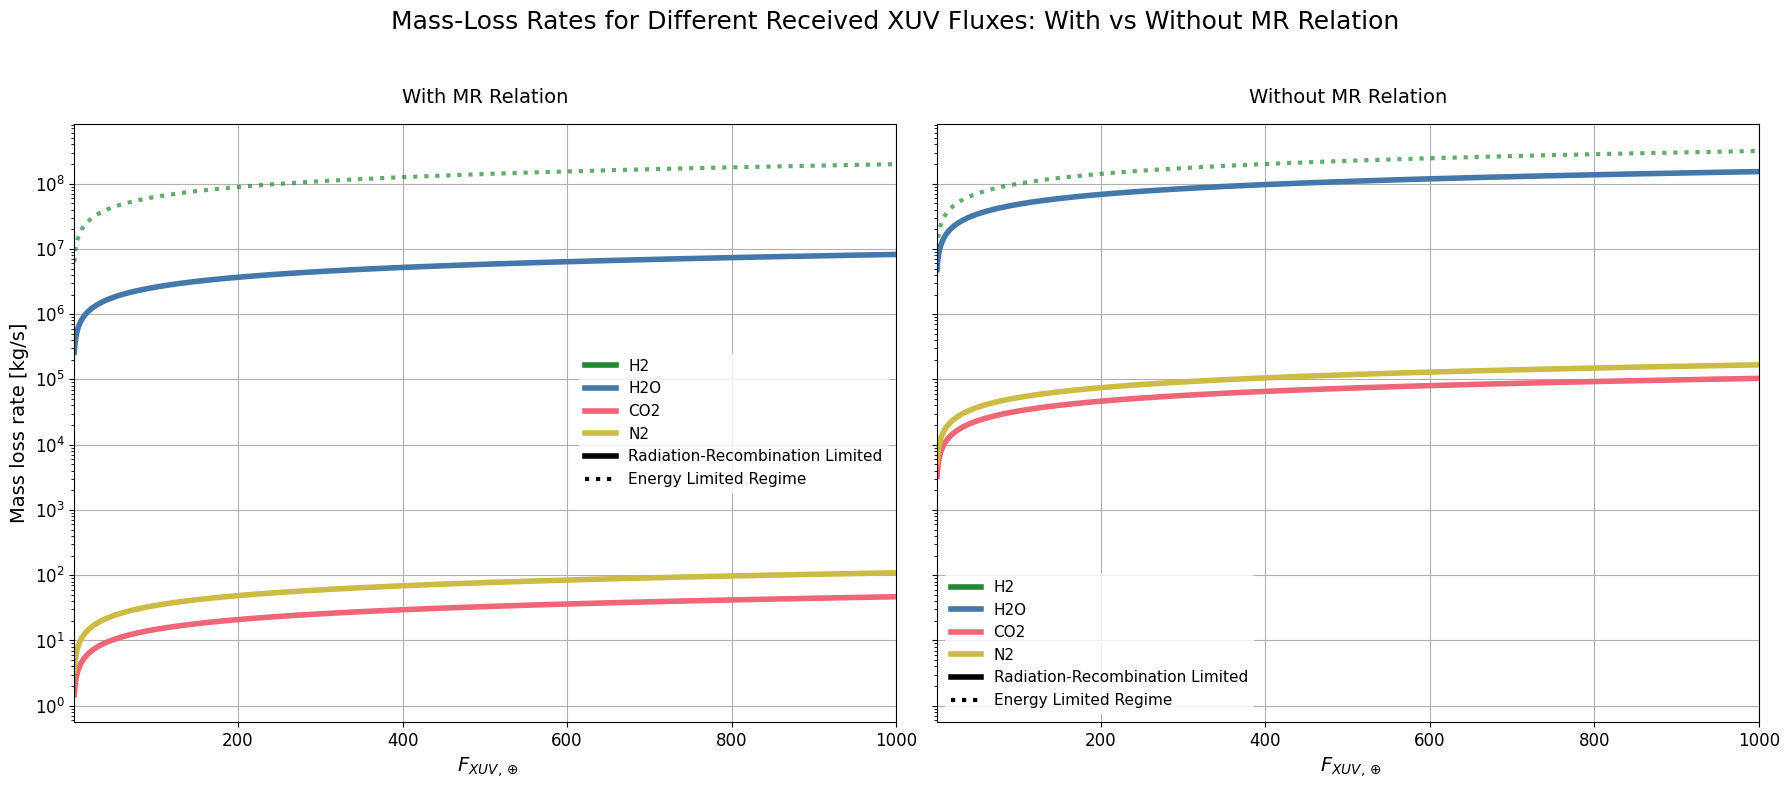

In [81]:
F_earth_xuv = 0.2196388835   #[W/m^2] XUV flux on Earth
Flux_array_xuv = np.logspace(0, 3, 1000) * F_earth_xuv #[W/m^2]
results_with_mr = {}
results_no_mr = {}

for species in species_microphysics.keys(): #for each species
    atm_with_mr = np.array([make_simple_atmosphere( #make at atmosphere where only the flux is varied but with MR relation
        M_p=8.41 * 5.9722 * 10**24,
        determine_radius=True,
        F_xuv=F,
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=5000,
        dominant_species=species) for F in Flux_array_xuv])

    M_dot_rr_with_mr, regime_break_with_mr, rr_mask_with_mr = sweep_parameter(atm_with_mr)
    results_with_mr[species] = (M_dot_rr_with_mr, regime_break_with_mr, rr_mask_with_mr)


    atm_no_mr = np.array([make_simple_atmosphere( #make at atmosphere where only the flux is varied but with no MR relation
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=F,
        mu_photo=species_microphysics[species]['mu_photo'],
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        P_0=2000,
        T_wind=10**4,
        T_eq=553,
        resolution=5000,
        dominant_species=species) for F in Flux_array_xuv])

    M_dot_rr_no_mr, regime_break_no_mr, rr_mask_no_mr = sweep_parameter(atm_no_mr)
    results_no_mr[species] = (M_dot_rr_no_mr, regime_break_no_mr, rr_mask_no_mr)

keys = list(results_with_mr.keys())
colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44', '#9933A5'] 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
fig.suptitle('Mass-Loss Rates for Different Received XUV Fluxes: With vs Without MR Relation', fontsize=18, y=0.98)
fluxes = Flux_array_xuv / F_earth_xuv

axes = [ax1, ax2]
datasets = [results_with_mr, results_no_mr]
titles = ["With MR Relation", "Without MR Relation"]

custom_lines = [Line2D([0], [0], color='black', linestyle='-', lw=4),
                Line2D([0], [0], color='black', linestyle=':', lw=3)]

for ax, data_dict, title in zip(axes, datasets, titles):
    ax.set_title(title, fontsize=14, pad=15)
    
    for i, species in enumerate(keys):
        mass_loss_rates_flux, regime_break_flux, rr_mask_flux = data_dict[species]
        
        ax.plot(fluxes, mass_loss_rates_flux, linestyle='dotted', color=colours[i], alpha=0.7, lw=3)
        ax.plot(fluxes[rr_mask_flux], np.array(mass_loss_rates_flux)[rr_mask_flux], linestyle='solid', color=colours[i], label=f'{species}', lw=4)

    handles, labels = ax.get_legend_handles_labels()
    handles.extend(custom_lines)
    labels.extend(['Radiation-Recombination Limited', 'Energy Limited Regime'])
    ax.legend(handles=handles, labels=labels, loc='best', fontsize=11, frameon=True, shadow=False, facecolor='white', edgecolor='none')
    ax.grid(True)
    ax.set_xlabel(' $F_{XUV,\oplus}$', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.tick_params(axis='both', which='minor', labelsize=10)
    ax.set_xlim(fluxes[0], fluxes[-1])

ax1.set_ylabel('Mass loss rate [kg/s]', fontsize=14)
ax1.set_yscale('log')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
#plt.savefig('Keepers/Flux_sweep.png', dpi=300)
plt.show()

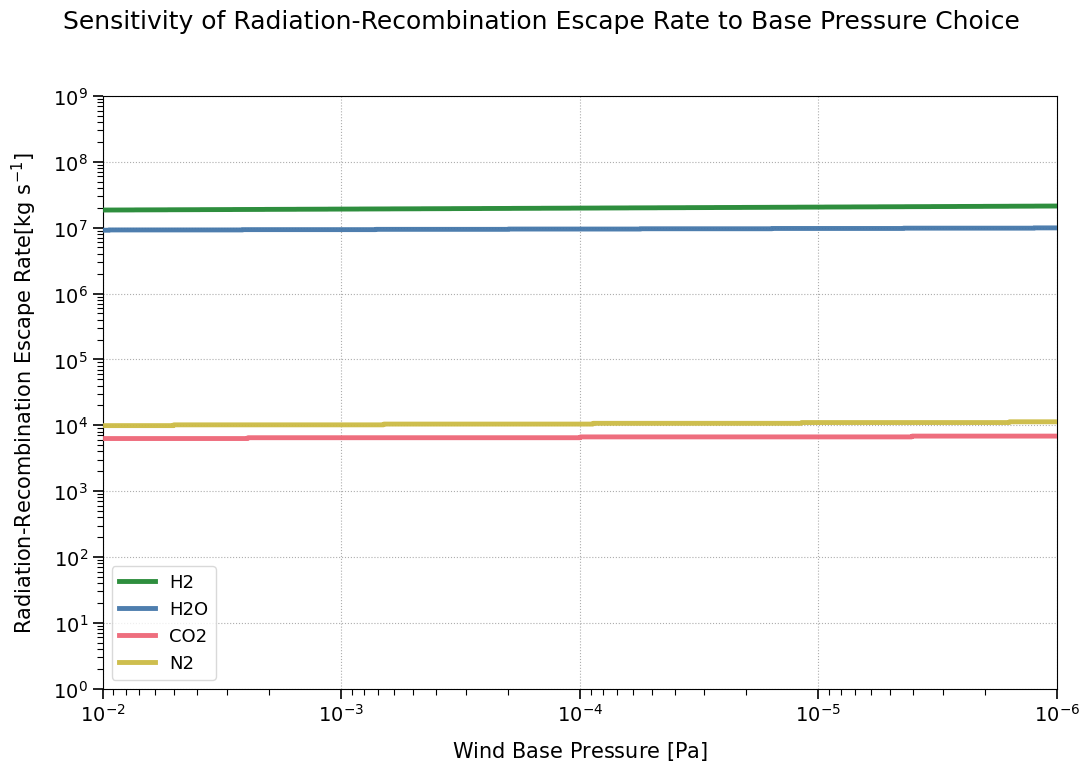

In [179]:
# --- 1. PARAMETER SWEEP OVER WIND BASE PRESSURES ---

# Using geomspace ensures your 3000 steps are evenly distributed across log decades 
# from 10^-2 Pa down to 10^-6 Pa
P_base_array = np.geomspace(10**(-2), 10**(-6), 3000) 

atmospheres_swept_P_base = {}
for species in species_microphysics.keys(): 
    atm_varied_P_base = [make_simple_atmosphere(
        M_p=8.41 * 5.9722 * 10**24,
        R_p=2.73 * 6.371 * 10**6,
        F_xuv=10**2.93 * erg_to_joule * cm_to_m**(-2),
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        T_eq=567,
        mu_photo=species_microphysics[species]['mu_photo'],
        P_base=P_base,
        T_wind=10**4,
        dominant_species=species,
    ) for P_base in P_base_array]
    
    # FIXED: Extracting ONLY the pure theoretical Rad-Recomb rates (M_dot_rr)
    _, _, M_dot_rr_P, _, _ = sweep_parameter(atm_varied_P_base)
    atmospheres_swept_P_base[species] = np.array(M_dot_rr_P)

keys = list(atmospheres_swept_P_base.keys())


# --- 2. HIGH-READABILITY THESIS PLOTTING ROUTINE ---

colours = ['#228833', '#4477AA', '#EE6677', '#CCBB44', '#9933A5']
fig, ax = plt.subplots(1, 1, figsize=(11, 8))
fig.suptitle(r'Sensitivity of Radiation-Recombination Escape Rate to Base Pressure Choice ', 
             fontsize=18, y=0.96)

# Plot each species as a single, uninterrupted continuous line
for i, species in enumerate(keys):
    pure_rr_mass_loss = atmospheres_swept_P_base[species]
    ax.plot(P_base_array, pure_rr_mass_loss, linestyle='solid', color=colours[i], 
            label=rf'{species}', lw=3.5, alpha=0.95, zorder=3)

# Figure Formatting for Thesis/Publication
ax.grid(True, alpha=0.6, linestyle=':', color='#777777', zorder=1)

# Pure LaTeX, un-bolded formatting for axis strings
ax.set_xlabel(r'Wind Base Pressure [$\mathrm{Pa}$]', fontsize=15, labelpad=10)
ax.set_ylabel(r'Radiation-Recombination Escape Rate[$\mathrm{kg\ s}^{-1}$]', fontsize=15, labelpad=10)

# Set both scales to log to observe potential power-law relationships cleanly
ax.set_xscale('log')
ax.set_yscale('log')

# Explicitly defining limits based on your calculation constraints
ax.set_xlim(P_base_array[0], P_base_array[-1])
ax.set_ylim(10**(0), 10**9)

# Clean, distinct tick formatting for log grids
ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.2)
ax.tick_params(axis='both', which='minor', labelsize=12, length=4, width=0.8)

# Legend clean up
ax.legend(loc='best', fontsize=13, frameon=True, facecolor='white', edgecolor='#d0d0d0')

plt.tight_layout(rect=[0, 0, 1, 0.93])
#plt.savefig('Keepers/P_base_sensitivity.png', dpi=300, bbox_inches='tight')
plt.show()

In [182]:
### Examine mass loss rates and regimes for all species and masses over specific star ###

# planet variables
semi_major_axis = np.logspace(-2, 1, 120) * au # Distance from 0.01 to 10 AU
masses_2D = np.linspace(0.9, 16.6, 90) * M_earth 

n_masses = len(masses_2D)
n_distances = len(semi_major_axis)

# star variables
M_s = 1 * solar_mass
age_s = 20 * 10**6 # years

# Compute the true 1D flux arrays corresponding to the distance track
F_bol_array, F_xuv_array = get_escape_fluxes(M_s, age_s, semi_major_axis)

atmospheres_swept_2D = {}

print("Computing 2D multi-species parameter grid...")
for species in species_microphysics.keys():
    print(f"Processing composition matrix: {species}")
    
    # 1. Build the complete 2D tracking matrix across Mass and Distance
    # Rows = Mass steps, Columns = Distance/Flux steps
    atms_varied_2D = np.array([[make_simple_atmosphere(
        M_p=M, 
        F_xuv=F_xuv,
        nu_0=species_microphysics[species]['nu_0'],
        mu_wind=species_microphysics[species]['mu_wind'],
        mu_plus_wind=species_microphysics[species]['mu_plus_wind'],
        T_eq=Atmosphere.determine_temperature_from_bolometric_flux(F_bol=F_b),
        mu_photo=species_microphysics[species]['mu_photo'],
        P_0=2000, 
        T_wind=10**4,
        dominant_species=species,
        resolution=6000,
        determine_radius=True
    ) for F_xuv, F_b in zip(F_xuv_array, F_bol_array)] for M in masses_2D])

    # 2. Flatten for batch processing
    atms_varied_flat = atms_varied_2D.flatten()
    
    # 3. Unpack all 5 variables under your new structural formalism
    M_dot_stitched_flat, rr_mask_flat, _, _, transonic_mask_flat = sweep_parameter(atms_varied_flat)

    # 4. Reshape to (n_masses, n_distances) and Transpose (.T) to align with (n_distances, n_masses)
    # This guarantees it precisely matches your meshgrid dimensions: X (Mass) and Y (Flux/Distance)
    Z_mdot = np.array(M_dot_stitched_flat).reshape((n_masses, n_distances)).T
    Z_mask = np.array(rr_mask_flat).reshape((n_masses, n_distances)).T.astype(float)
    Z_transonic = np.array(transonic_mask_flat).reshape((n_masses, n_distances)).T.astype(float)
    
    # Store calculated matrices back into target dictionary structure
    atmospheres_swept_2D[species] = {
        'M_dot_stitched': Z_mdot,
        'rr_mask': Z_mask,
        'transonic_mask': Z_transonic,
    }


Computing 2D multi-species parameter grid...
Processing composition matrix: H2
Processing composition matrix: H2O
Processing composition matrix: CO2
Processing composition matrix: N2


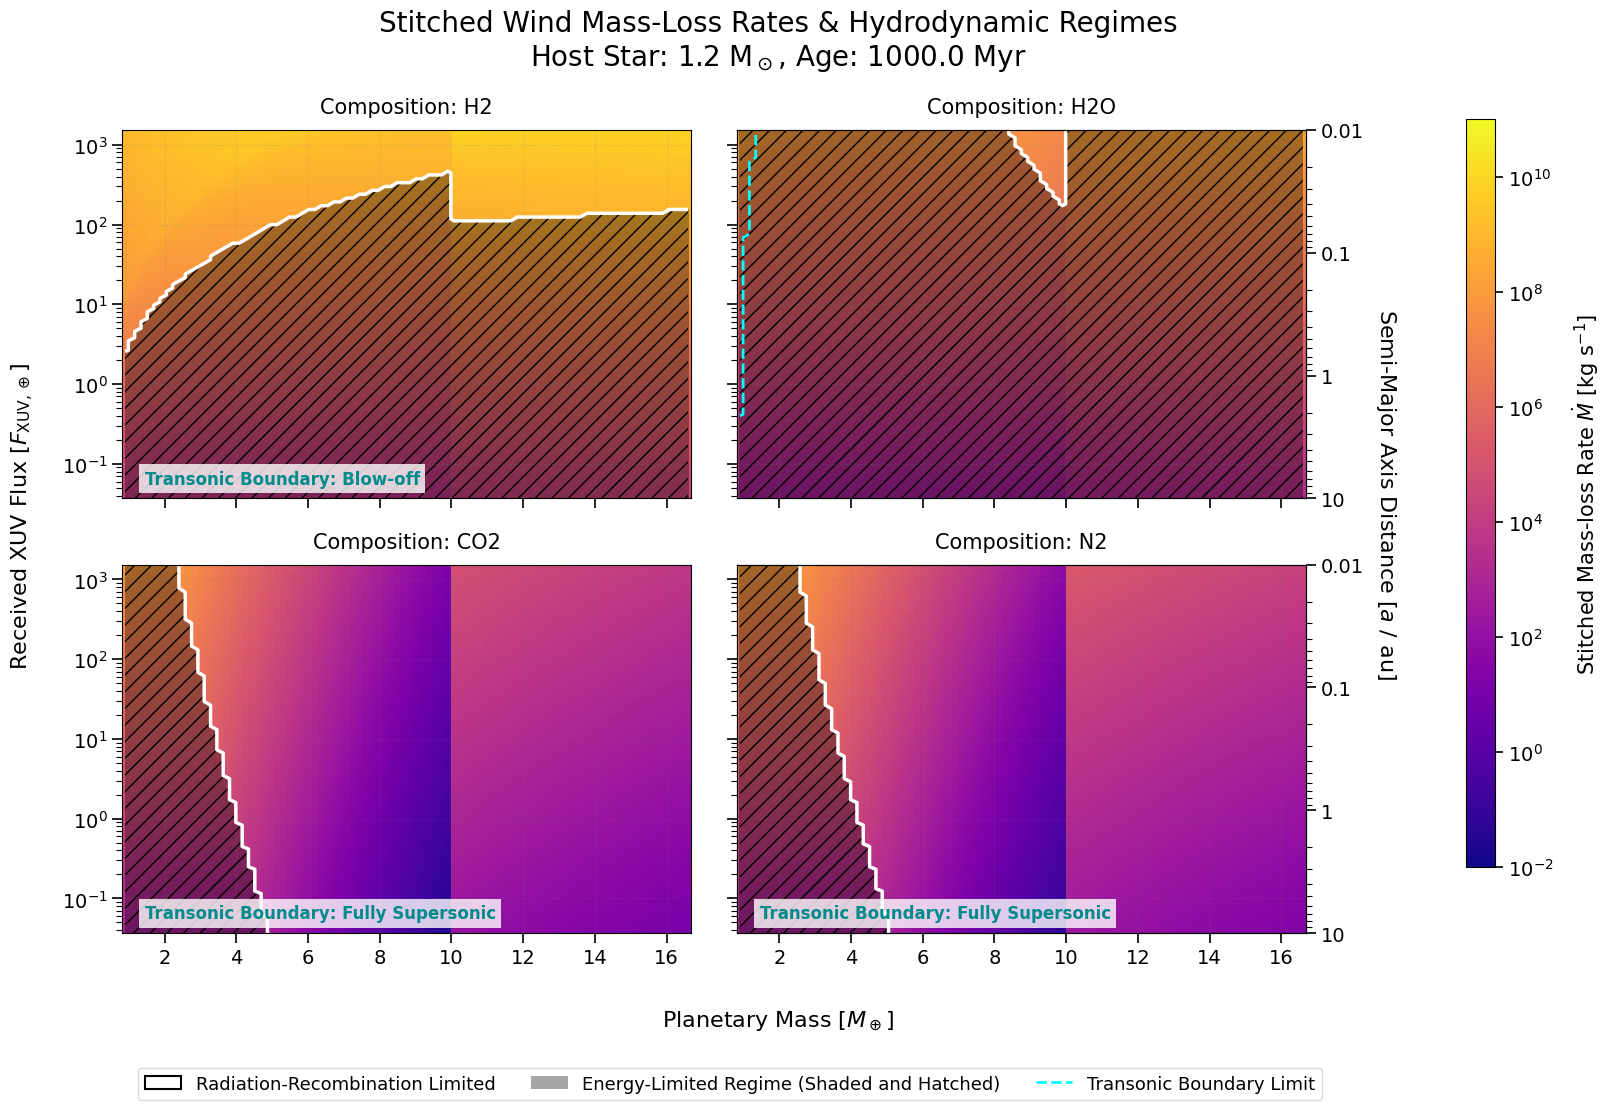

In [ ]:
# 1. Initialize 2x2 multi-panel layout canvas
fig, axes = plt.subplots(2, 2, figsize=(16, 11), sharex=True, sharey=True)
axes = axes.flatten()

# Standardize plot coordinate arrays for thesis normalization
masses_plot = masses_2D / M_earth
fluxes_plot = F_xuv_array / F_earth_xuv

# Build 2D meshgrid coordinates: X (Mass), Y (Received XUV Flux)
X, Y = np.meshgrid(masses_plot, fluxes_plot)

# 2. Iterate through species structures dynamically
for i, species in enumerate(keys):
    ax = axes[i]
    
    # Extract calculations (Pre-shaped & transposed by the meshgrid generation loop)
    Z_mdot = atmospheres_swept_2D[species]['M_dot_stitched']
    
    # Invert the mask so that True (1.0) maps directly to the Energy-Limited region
    Z_el_mask = (~atmospheres_swept_2D[species]['rr_mask'].astype(bool)).astype(float)
    Z_transonic = atmospheres_swept_2D[species]['transonic_mask']
    
    # Render background continuous stitched mass loss field
    pcm = ax.pcolormesh(X, Y, Z_mdot, norm=colors.LogNorm(vmin=1e-2, vmax=1e11), cmap='plasma', shading='auto')

    # REGIME 1: Shaded block overlay covering the Energy-Limited domain data points
    ax.contourf(X, Y, Z_el_mask, levels=[0.5, 1.5], colors='black', alpha=0.35, hatches=['//']) 
    
    # Clean white boundary line separating the active theoretical regions
    ax.contour(X, Y, Z_el_mask, levels=[0.5], colors='white', linewidths=2.5)
    
    # -------------------------------------------------------------------------
    # TRANSONIC BORDER LOGIC
    # -------------------------------------------------------------------------
    # Check if the grid actually contains a transition (mix of True and False)
    if Z_transonic.max() > Z_transonic.min():
        # A boundary exists; draw the dashed contour line
        ax.contour(X, Y, Z_transonic, levels=[0.5], colors='cyan', linewidths=2.0, linestyles='dashed')
    else:
        # No boundary exists. Determine the uniform state across the entire grid.
        # Assuming 0.0 means sub-sonic and 1.0 means super-sonic based on your mask
        state_text = "Blow-off" if Z_transonic.max() == 0 else "Fully Supersonic"
        
        # Place a subtle, professional text box in the bottom-left corner of this specific subplot
        ax.text(0.04, 0.04, f"Transonic Boundary: {state_text}", 
                transform=ax.transAxes, fontsize=12, color='darkcyan', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=4), zorder=5)
    
    # Subplot individual formatting setups
    ax.set_title(rf'Composition: {species}', fontsize=15, pad=12)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, linestyle=':', color='#777777', zorder=1)
    ax.set_ylim(fluxes_plot.min(), fluxes_plot.max())

    ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.2)
    ax.tick_params(axis='both', which='minor', labelsize=12, length=4, width=0.8)
    
    # -----------------------------------------------------------------------------------------
    # CONFIGURING THE SECONDARY RIGHT AXIS (Distance Transformation Mapping)
    # -----------------------------------------------------------------------------------------
    if i in [1, 3]:
        ax_right = ax.twinx()
        ax_right.set_yscale('log')
        
        # Directly map the physical boundaries of your semi_major_axis array
        dist_min = semi_major_axis.min() / au
        dist_max = semi_major_axis.max() / au
        ax_right.set_ylim(dist_max, dist_min) # Inverted order maps high flux to small distance
        
        # Force clean decimal formats
        ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
        ax_right.yaxis.set_minor_formatter(ticker.NullFormatter())
        
        ax_right.tick_params(axis='y', which='major', labelsize=14, length=7, width=1.2)
        ax_right.tick_params(axis='y', which='minor', length=4, width=0.8)

# 3. Create global labels and shared formatting parameters (Thesis Minimalist Theme)
active_patch = patches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, 
                              label='Radiation-Recombination Limited')
el_patch = patches.Patch(facecolor='black', alpha=0.35, edgecolor='none', 
                           label='Energy-Limited Regime (Shaded and Hatched)', hatch='//')
trans_line = Line2D([0], [0], color='cyan', linewidth=2.0, linestyle='--', 
                    label='Transonic Boundary Limit')

# Unified global legend bar placement below the plots
fig.legend(handles=[active_patch, el_patch, trans_line], 
           loc='lower center', bbox_to_anchor=(0.47, -0.04), 
           ncol=4, fontsize=13, 
           frameon=True, facecolor='white', edgecolor='#d0d0d0') 

# Padding adjustment to safely isolate labels without running off clipping zones
plt.subplots_adjust(left=0.09, right=0.83, hspace=0.18, wspace=0.08, bottom=0.12, top=0.85)

# Global canvas text and annotations using un-bolded mathematical font structures
fig.suptitle(r'Stitched Wind Mass-Loss Rates & Hydrodynamic Regimes' + '\n' +
             f'Host Star: {M_s/solar_mass:.1f} ' + r'$\mathrm{M}_\odot$, Age: ' + f'{age_s/1e6:.1f} Myr', 
             fontsize=20, y=0.96)

fig.supxlabel(r'Planetary Mass [$M_\oplus$]', fontsize=16, y=0.03)
fig.supylabel(r'Received XUV Flux [$F_{\mathrm{XUV},\oplus}$]', fontsize=16, x=0.02)

# Single global right-hand title for secondary twinx distance axis
fig.text(0.88, 0.52, r'Semi-Major Axis Distance [$a\mathrm{\ /\ au}$]', fontsize=16, rotation=-90, va='center', ha='center')

# Colorbar axis anchor layout coordinates
cbar_ax = fig.add_axes([0.93, 0.18, 0.018, 0.68])
cbar = fig.colorbar(pcm, cax=cbar_ax)

cbar.set_label(r'Stitched Mass-loss Rate $\dot{M}$ [$\mathrm{kg\ s}^{-1}$]', fontsize=15, labelpad=12)
cbar_ax.tick_params(axis='y', which='major', labelsize=14, length=6, width=1.2)
# plt.savefig('Keepers/Coupled_Stellar_Grid_Sweep.png', dpi=300, bbox_inches='tight')
plt.show()

In [189]:
# planet variables
semi_major_axis = np.logspace(-2, 1, 120) * au # Distance from 0.01 to 10 AU
masses_2D = np.linspace(0.9, 16.6, 90) * M_earth  # Planet mass from 0.5 to 30 M_earth

n_masses = len(masses_2D)
n_distances = len(semi_major_axis)

# Isolate the microphysics strictly for water
h2o_specs = species_microphysics['H2O']

masses_plot = masses_2D / M_earth
computed_data_h2o = []  # To store results for each case

print("Beginning multi-case stellar evolution sweep for H2O atmospheres...")
for case in stellar_cases:
    M_s = case['M_star'] * solar_mass
    age_s = case['age']
    print(f"Running Grid: M_star = {case['M_star']} M_sun | Age = {age_s/1e6:.1f} Myr")
    
    F_bol_array, F_xuv_array = get_escape_fluxes(M_s, age_s, semi_major_axis)
    
    fluxes_plot = F_xuv_array / F_earth_xuv
    X, Y = np.meshgrid(masses_plot, fluxes_plot)
    
    # Run the computational grid (Resolution optimized to 6000)
    atms_varied_2D = np.array([[make_simple_atmosphere(
        M_p=M, 
        determine_radius=True, 
        F_xuv=F_xuv,
        nu_0=h2o_specs['nu_0'],
        mu_wind=h2o_specs['mu_wind'],
        mu_plus_wind=h2o_specs['mu_plus_wind'],
        mu_photo=h2o_specs['mu_photo'],         
        P_0=2000, 
        T_wind=10**4,
        T_eq=Atmosphere.determine_temperature_from_bolometric_flux(F_bol=F_b),
        resolution=6000, 
        dominant_species='H2O'
    ) for F_xuv, F_b in zip(F_xuv_array, F_bol_array)] for M in masses_2D])

    # Flatten and sweep
    atms_varied_flat = atms_varied_2D.flatten()
    
    # FIXED: Unpacking all 5 values according to the new structural formalism
    M_dot_flat, rr_mask_flat, _, _, transonic_mask_flat = sweep_parameter(atms_varied_flat)

    # Reconstruct 2D matrices (Reshaping then transposing to match your X, Y meshgrids)
    Z_mdot = np.array(M_dot_flat).reshape((n_masses, n_distances)).T
    Z_mask = np.array(rr_mask_flat).reshape((n_masses, n_distances)).T.astype(float)
    Z_transonic = np.array(transonic_mask_flat).reshape((n_masses, n_distances)).T.astype(float)
    
    # Store the results for plotting, including the new transonic tracks
    computed_data_h2o.append({
        'case': case, 
        'X': X, 
        'Y': Y, 
        'Z_mdot': Z_mdot, 
        'Z_mask': Z_mask, 
        'Z_transonic': Z_transonic,
        'fluxes_plot': fluxes_plot
    })

print("Multi-case sweep complete.")

Beginning multi-case stellar evolution sweep for H2O atmospheres...
Running Grid: M_star = 0.7 M_sun | Age = 20.0 Myr
Running Grid: M_star = 0.7 M_sun | Age = 1000.0 Myr
Running Grid: M_star = 1.0 M_sun | Age = 20.0 Myr
Running Grid: M_star = 1.0 M_sun | Age = 1000.0 Myr
Running Grid: M_star = 1.2 M_sun | Age = 20.0 Myr
Running Grid: M_star = 1.2 M_sun | Age = 1000.0 Myr
Multi-case sweep complete.


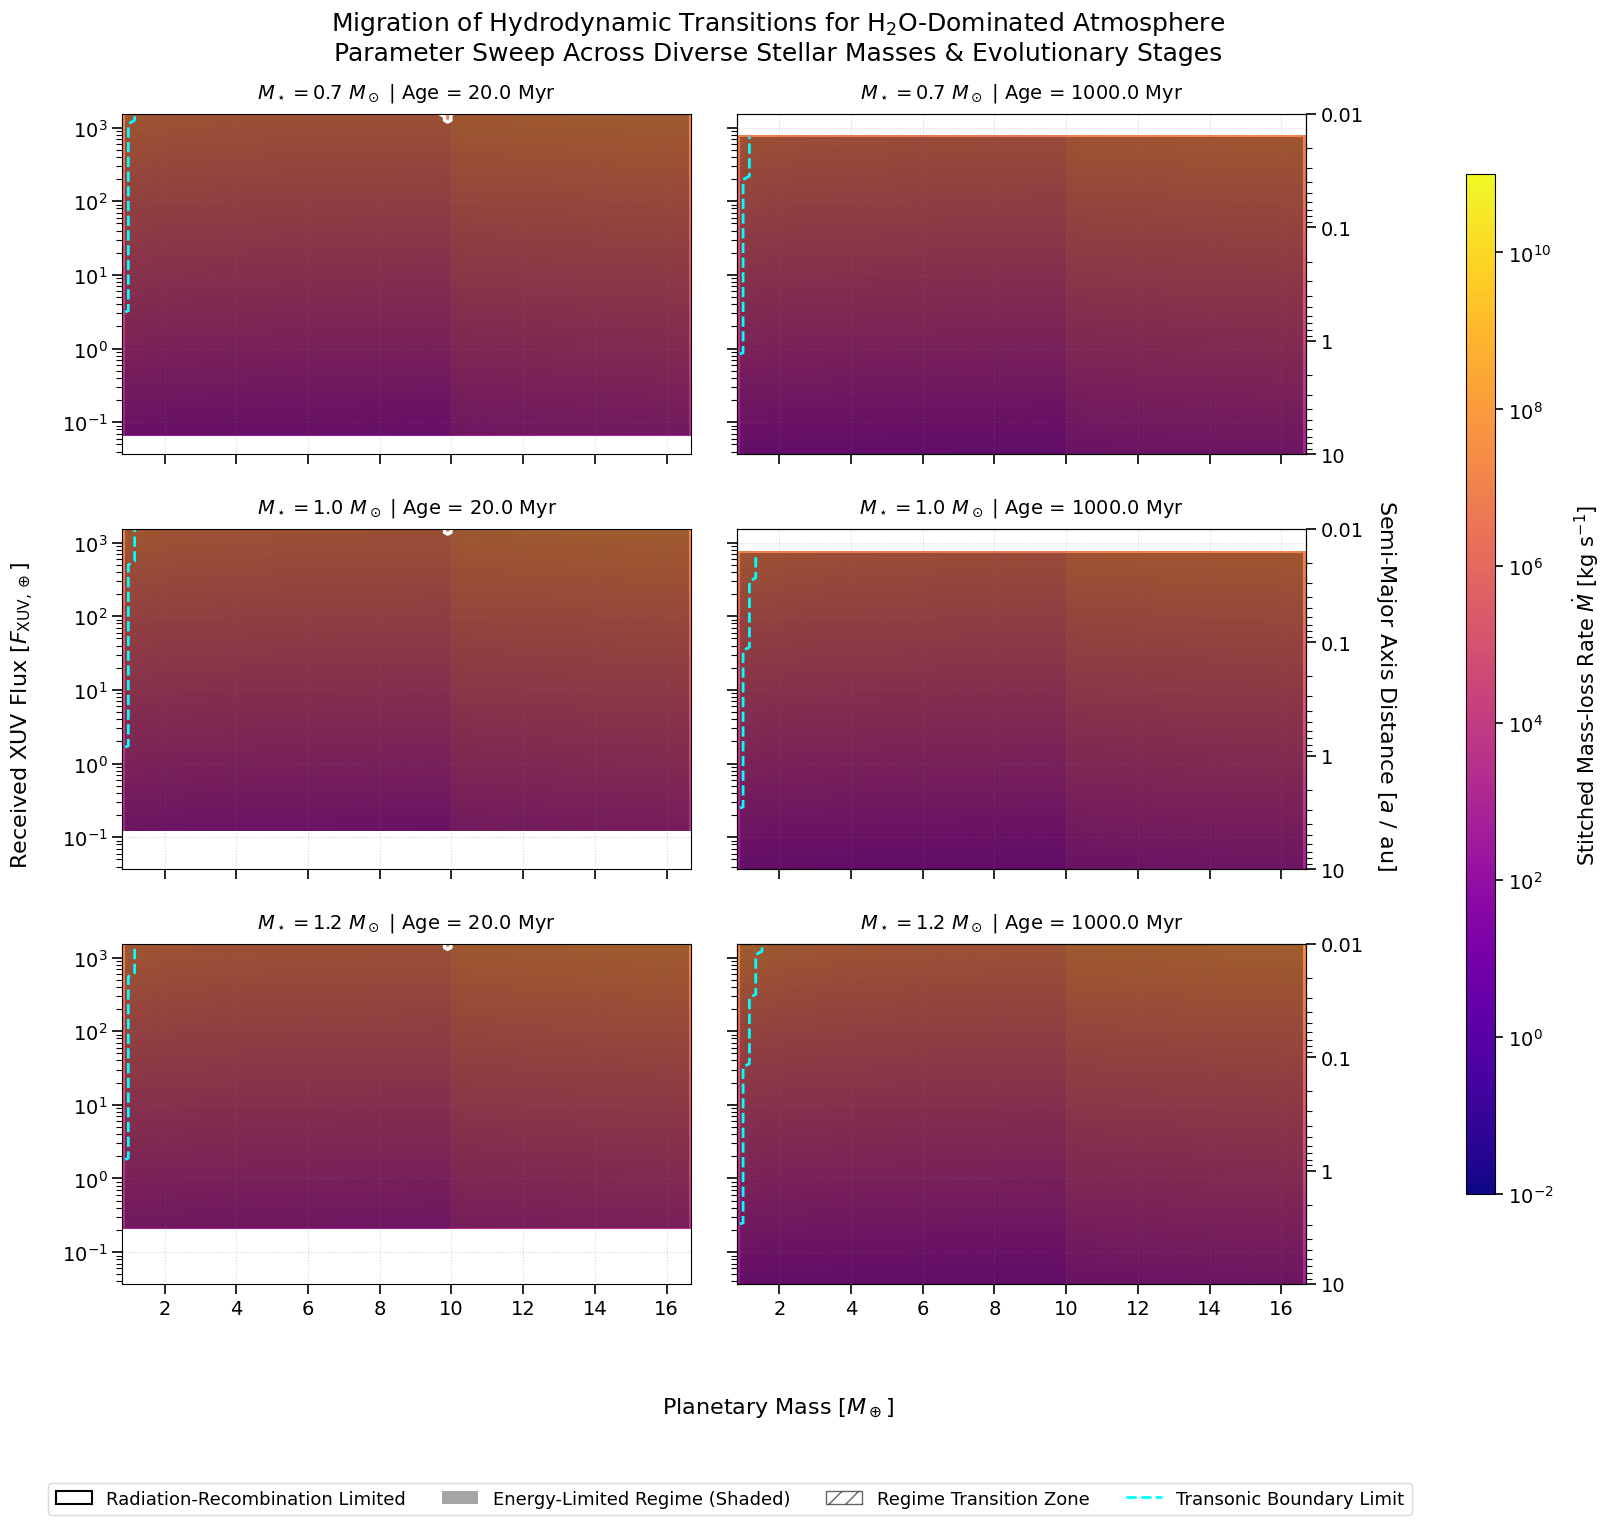

In [ ]:
# --- DYNAMIC GRID CALCULATION ---
num_plots = len(computed_data_h2o)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

# Initialize multi-panel layout canvas dynamically based on dataset length
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 5 * num_rows), sharex=True, sharey=True)

# Flatten the axes array to easily iterate over individual subplots
if num_plots == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

# 2. Iterate through your computed dataset list dynamically
for i, data in enumerate(computed_data_h2o):
    ax = axes[i]
    
    # --- DIRECT DICTIONARY EXTRACTION ---
    case = data['case']
    X = data['X']
    Y = data['Y']
    Z_mdot = data['Z_mdot']
    fluxes_plot = data['fluxes_plot']
    
    # Invert the dictionary mask so that True (1.0) maps directly to the Energy-Limited region
    Z_el_mask = (~data['Z_mask'].astype(bool)).astype(float)
    Z_transonic = data['Z_transonic']
    
    # Render background continuous stitched mass loss field using extracted meshgrids
    pcm = ax.pcolormesh(X, Y, Z_mdot, norm=colors.LogNorm(vmin=1e-2, vmax=1e11), cmap='plasma', shading='auto')

    # REGIME 1: Shaded block overlay covering the Energy-Limited domain data points
    ax.contourf(X, Y, Z_el_mask, levels=[0.5, 1.5], colors='black', alpha=0.35) 

    # REGIME BREAK: Add a distinct hatched pattern right along the crossover interface transition
    ax.contourf(X, Y, Z_el_mask, levels=[0.4, 0.6], colors='none', hatches=['//'], alpha=0.4)
    
    # Clean white boundary line separating the active theoretical regions
    ax.contour(X, Y, Z_el_mask, levels=[0.5], colors='white', linewidths=2.5)
    
    # -------------------------------------------------------------------------
    # TRANSONIC BORDER LOGIC
    # -------------------------------------------------------------------------
    if Z_transonic.max() > Z_transonic.min():
        ax.contour(X, Y, Z_transonic, levels=[0.5], colors='cyan', linewidths=2.0, linestyles='dashed')
    else:
        state_text = "Fully Subsonic" if Z_transonic.max() == 0 else "Fully Supersonic"
        ax.text(0.04, 0.04, f"Transonic Boundary: {state_text}", 
                transform=ax.transAxes, fontsize=11, color='darkcyan', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=4), zorder=5)
    
    # Subplot title mapping
    ax.set_title(rf"$M_\star = {case['M_star']:.1f}\ M_\odot$ | Age = {case['age']/1e6:.1f} Myr", fontsize=14, pad=12)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, linestyle=':', color='#777777', zorder=1)
    ax.set_ylim(fluxes_plot.min(), fluxes_plot.max())

    ax.tick_params(axis='both', which='major', labelsize=14, length=7, width=1.2)
    ax.tick_params(axis='both', which='minor', labelsize=12, length=4, width=0.8)
    
    # -------------------------------------------------------------------------
    # CONFIGURING THE SECONDARY RIGHT AXIS (Only on the rightmost column)
    # -------------------------------------------------------------------------
    if (i % num_cols) == (num_cols - 1):
        ax_right = ax.twinx()
        ax_right.set_yscale('log')
        
        dist_min = semi_major_axis.min() / au
        dist_max = semi_major_axis.max() / au
        ax_right.set_ylim(dist_max, dist_min) 
        
        ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
        ax_right.yaxis.set_minor_formatter(ticker.NullFormatter())
        
        ax_right.tick_params(axis='y', which='major', labelsize=14, length=7, width=1.2)
        ax_right.tick_params(axis='y', which='minor', length=4, width=0.8)

# --- CLEAN UP UNUSED SUBPLOTS ---
# If your dataset length is odd, turn off the empty subplots so they don't show blank boxes
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# 3. Legend & Shared Formatting
active_patch = patches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, label='Radiation-Recombination Limited')
el_patch = patches.Patch(facecolor='black', alpha=0.35, edgecolor='none', label='Energy-Limited Regime (Shaded)')
hatch_patch = patches.Patch(facecolor='none', edgecolor='black', hatch='//', alpha=0.6, label='Regime Transition Zone')
trans_line = Line2D([0], [0], color='cyan', linewidth=2.0, linestyle='--', label='Transonic Boundary Limit')

fig.legend(handles=[active_patch, el_patch, hatch_patch, trans_line], 
           loc='lower center', bbox_to_anchor=(0.47, -0.04), 
           ncol=4, fontsize=13, frameon=True, facecolor='white', edgecolor='#d0d0d0') 

# Padding adjustment dynamically keeps space at the top depending on the number of rows
top_spacing = 0.86 if num_rows == 2 else 0.90
plt.subplots_adjust(left=0.09, right=0.83, hspace=0.22, wspace=0.08, bottom=0.12, top=top_spacing)

fig.suptitle(r'Migration of Hydrodynamic Transitions for $\mathrm{H_2O}$-Dominated Atmosphere' + '\n' +
             r'Parameter Sweep Across Diverse Stellar Masses & Evolutionary Stages', 
             fontsize=18, y=0.97)

fig.supxlabel(r'Planetary Mass [$M_\oplus$]', fontsize=16, y=0.03)
fig.supylabel(r'Received XUV Flux [$F_{\mathrm{XUV},\oplus}$]', fontsize=16, x=0.02)

fig.text(0.88, 0.52, r'Semi-Major Axis Distance [$a\mathrm{\ /\ au}$]', fontsize=16, rotation=-90, va='center', ha='center')

# Colorbar anchor
cbar_ax = fig.add_axes([0.93, 0.18, 0.018, 0.68])
cbar = fig.colorbar(pcm, cax=cbar_ax)
cbar.set_label(r'Stitched Mass-loss Rate $\dot{M}$ [$\mathrm{kg\ s}^{-1}$]', fontsize=15, labelpad=12)
cbar_ax.tick_params(axis='y', which='major', labelsize=14, length=6, width=1.2)

plt.show()

In [ ]:
### Check how the regime break migrates for CO2 dominated atmosphere ###
# planet variables
semi_major_axis = np.logspace(-2, 1, 120) * au # Distance from 0.01 to 10 AU
masses_2D = np.linspace(0.9, 16.6, 90) * M_earth  # Planet mass from

n_masses = len(masses_2D)
n_distances = len(semi_major_axis)

# Define the 4 distinct host star cases to populate the subplots
stellar_cases = [
    {'M_star': 0.7,  'age': 20.0 * 10**6, 'label': 'Young K-Dwarf (0.7 M$_\odot$, 20 Myr)'},
    {'M_star': 0.7,  'age': 1.0 * 10**9, 'label': 'Older K-Dwarf (0.7 M$_\odot$, 1 Gyr)'},
    {'M_star': 1.0,  'age': 20.0 * 10**6, 'label': 'Young G-Dwarf (1.0 M$_\odot$, 20 Myr)'},
    {'M_star': 1.0,  'age': 1.0 * 10**9, 'label': 'Older G-Dwarf (1.0 M$_\odot$, 1 Gyr)'},
    {'M_star': 1.20,  'age': 20.0 * 10**6, 'label': 'Young F-Dwarf (1.20 M$_\odot$, 20 Myr)'},
    {'M_star': 1.20,  'age': 1.0 * 10**9, 'label': 'Older F-Dwarf (1.20 M$_\odot$, 1 Gyr)'}
]

# Isolate the microphysics strictly for CO2
co2_specs = species_microphysics['CO2']

masses_plot = masses_2D / M_earth
computed_data_CO2 = []  # To store results for each case

for case in stellar_cases:
    M_s = case['M_star'] * solar_mass
    age_s = case['age']
    F_bol_array, F_xuv_array = get_escape_fluxes(M_s, age_s, semi_major_axis)
    
    fluxes_plot = F_xuv_array / F_earth_xuv
    X, Y = np.meshgrid(masses_plot, fluxes_plot)
    
    # Run the computational grid
    atms_varied_2D = np.array([[make_simple_atmosphere(
        M_p=M, determine_radius=True, F_xuv=F_xuv,
        mu_photo=co2_specs['mu_photo'],
        P_0=2000, T_wind=10**4,
        T_eq=Atmosphere.determine_temperature_from_bolometric_flux(F_bol=F_b),
        resolution=4000, dominant_species='CO2'
    ) for F_xuv, F_b in zip(F_xuv_array, F_bol_array)] for M in masses_2D])

    # Flatten and sweep
    atms_varied_flat = atms_varied_2D.flatten()
    M_dot_flat, regime_break, rr_mask_flat = sweep_parameter(atms_varied_flat)

    Z_mdot = np.array(M_dot_flat).reshape((n_masses, n_distances)).T
    Z_mask = np.array(rr_mask_flat).reshape((n_masses, n_distances)).T.astype(float)
    
    # Store the results for plotting
    computed_data_CO2.append({
        'case': case, 'X': X, 'Y': Y, 
        'Z_mdot': Z_mdot, 'Z_mask': Z_mask, 
        'fluxes_plot': fluxes_plot
    })



<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:16: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:16: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\3144383309.py:11: SyntaxWarning: invalid escape sequence '\o'
  {'M_star': 0.7,  'age': 20.0 * 10**6, 'label': 'Young K-Dwarf (0.7 M$_\odot$, 20 Myr)'},
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\3144383309.py:12: SyntaxWarning: invalid escape sequence '\o'
  {'M_star': 0.7,  'age': 1.0 * 10**9, 'label': 'Older K-Dwarf (0.7 M$_\o

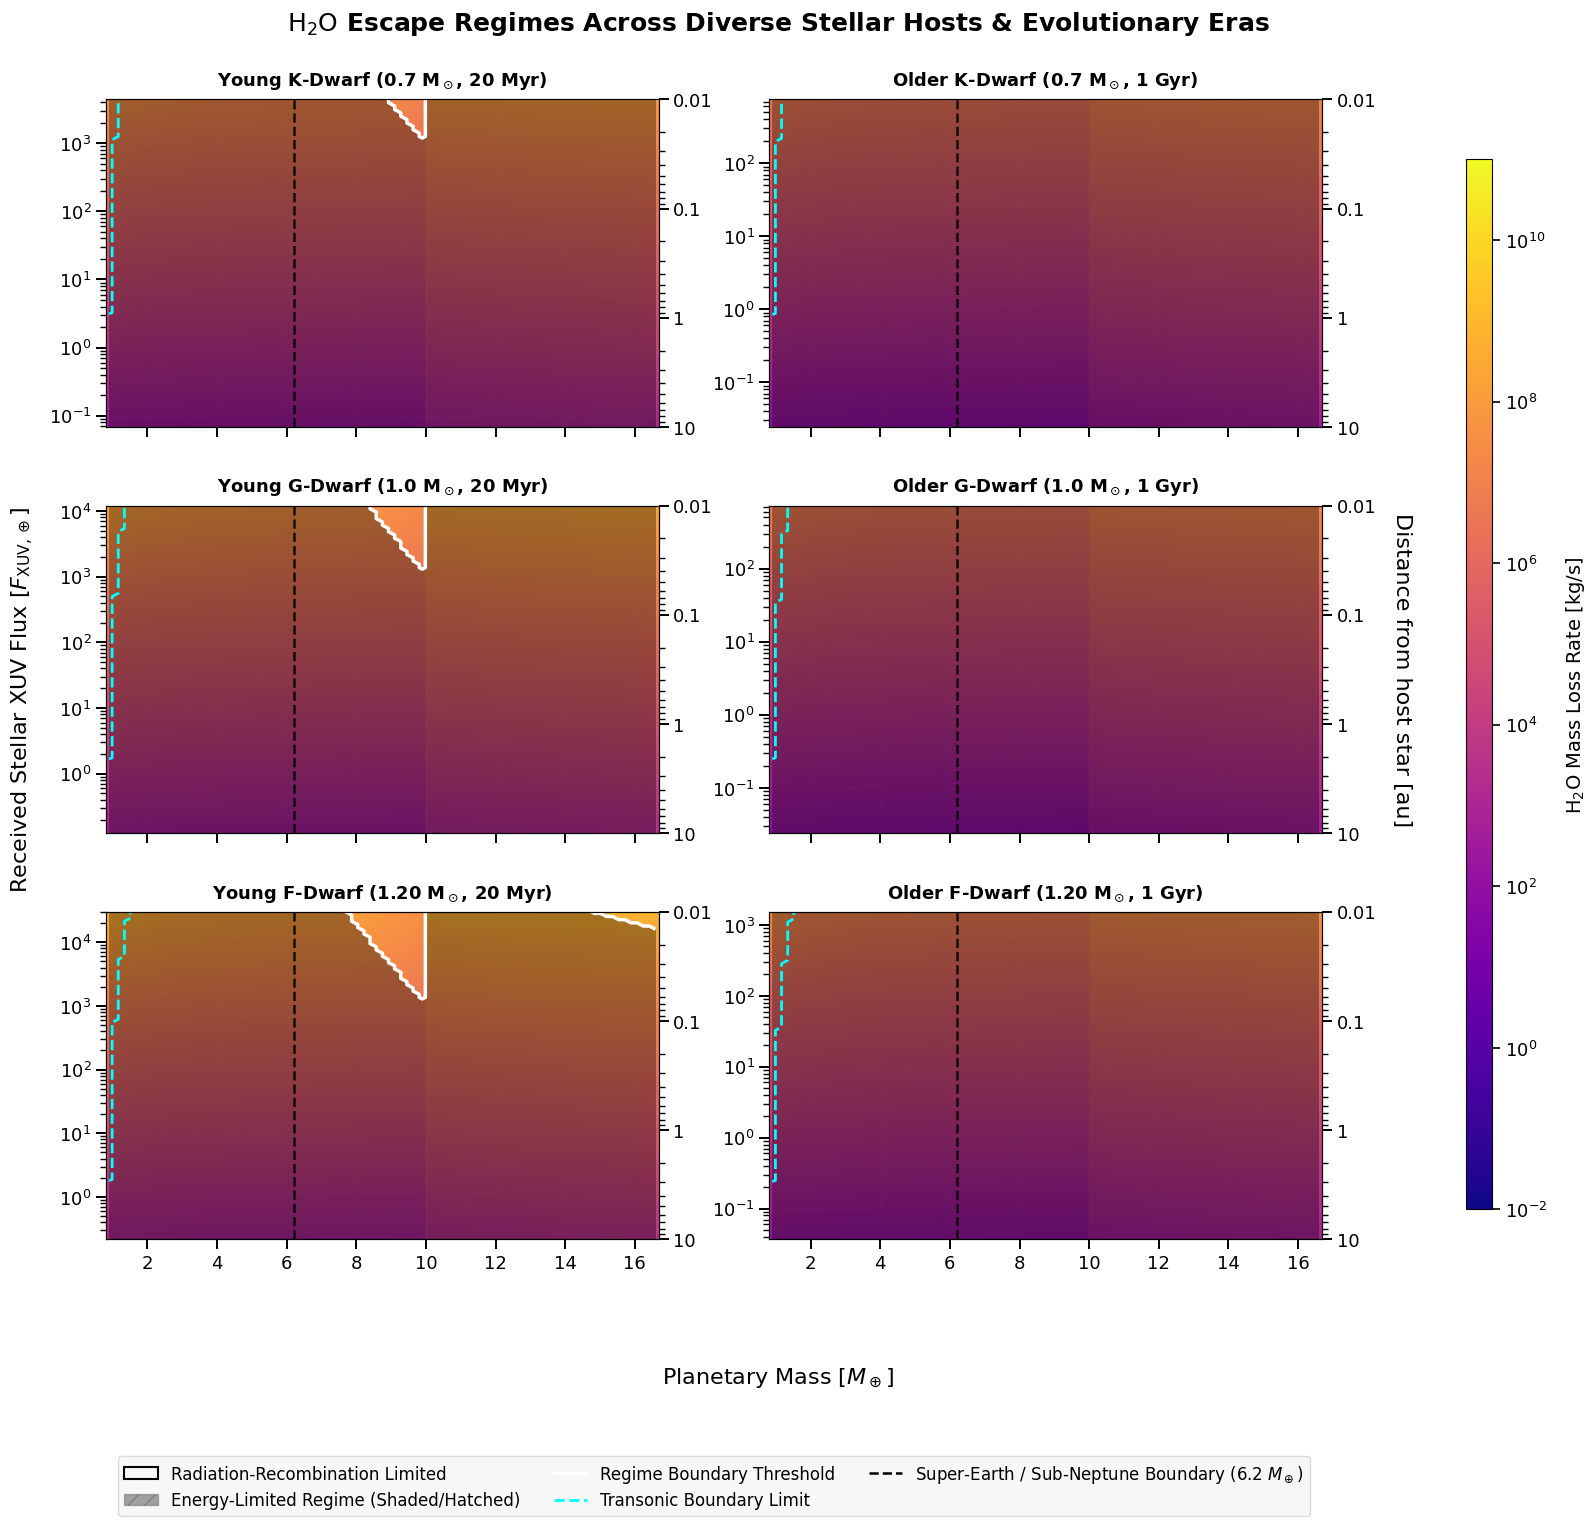

In [ ]:
# --- 1. DYNAMIC GRID SETUP ---
num_plots = len(computed_data_h2o)
num_cols = 2
num_rows = math.ceil(num_plots / num_cols)

# CRITICAL FIX: sharey=False allows each unique star to display its true, unwarped XUV flux scaling
fig, axes = plt.subplots(num_rows, num_cols, figsize=(16, 5 * num_rows), sharex=True, sharey=False)

if num_plots == 1:
    axes = np.array([axes])
else:
    axes = axes.flatten()

last_pcm = None  # To track for the global colorbar

# --- 2. RENDER THE GRAPHICS SCENARIOS ---
for i, data in enumerate(computed_data_h2o):
    ax = axes[i]
    
    # Extract unique stellar case data shapes directly from your dictionary
    case = data['case']
    X = data['X']
    Y = data['Y']
    Z_mdot = data['Z_mdot']
    fluxes_plot = data['fluxes_plot']
    
    # Invert the dictionary mask so that True (1.0) maps to Energy-Limited (Shaded)
    # Your mask uses 0.0 for Energy-Limited and 1.0 for RR-Limited based on your reference script
    Z_el_mask = (~data['Z_mask'].astype(bool)).astype(float)
    Z_transonic = data['Z_transonic']
    
    # -----------------------------------------------------------------------------------------
    # SCALE CONFIGURATION FIRST (Forces correct log-space interpolation for contours)
    # -----------------------------------------------------------------------------------------
    ax.set_yscale('log')
    ax.set_ylim(fluxes_plot.min(), fluxes_plot.max())
    
    # Render background continuous stitched mass loss field
    pcm = ax.pcolormesh(X, Y, Z_mdot, norm=colors.LogNorm(vmin=1e-2, vmax=1e11), cmap='plasma', shading='auto')
    last_pcm = pcm  
    
    # Underlay the regime masks using the clean formatting configuration
    ax.contourf(X, Y, Z_el_mask, levels=[0.5, 1.5], colors='black', alpha=0.35, zorder=2) 
    ax.contourf(X, Y, Z_el_mask, levels=[0.4, 0.6], colors='none', hatches=['//'], alpha=0.4, zorder=2)
    ax.contour(X, Y, Z_el_mask, levels=[0.5], colors='white', linewidths=2.5, zorder=2)
    
    # -----------------------------------------------------------------------------------------
    # TRANSONIC BORDER TRACKING LOGIC
    # -----------------------------------------------------------------------------------------
    if Z_transonic.max() > Z_transonic.min():
        ax.contour(X, Y, Z_transonic, levels=[0.5], colors='cyan', linewidths=2.0, linestyles='dashed', zorder=3)
    else:
        state_text = "Fully Subsonic" if Z_transonic.max() == 0 else "Fully Supersonic"
        ax.text(0.04, 0.04, f"Wind: {state_text}", 
                transform=ax.transAxes, fontsize=11, color='darkcyan', fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=4), zorder=5)
        
    # -----------------------------------------------------------------------------------------
    # RESTORED: Demographic boundary line (6.2 Earth Masses)
    # -----------------------------------------------------------------------------------------
    ax.axvline(6.2, color='black', linestyle='--', linewidth=1.8, alpha=0.85, zorder=4)
    
    # Individual Panel Formatting
    # Checks if your dictionary stores title labels inside case['label'], falls back to mass/age if not
    title_string = case.get('label', rf"$M_\star = {case['M_star']:.1f}\ M_\odot$ | Age = {case['age']/1e6:.1f} Myr")
    ax.set_title(title_string, fontsize=13, weight='bold', pad=10)
    ax.grid(True, alpha=0.15, linestyle=':')
    
    ax.tick_params(axis='both', which='major', labelsize=13, length=7, width=1.4)
    ax.tick_params(axis='both', which='minor', labelsize=10, length=4, width=1.0)
    
    # -----------------------------------------------------------------------------------------
    # RIGHT SIDE SECONDARY AXIS (Unwarped Physical Distance Mapping)
    # -----------------------------------------------------------------------------------------
    # We display the twin axis on every subplot panel now since sharey is turned off
    ax_right = ax.twinx()
    ax_right.set_yscale('log')
    
    dist_min = semi_major_axis.min() / au
    dist_max = semi_major_axis.max() / au
    ax_right.set_ylim(dist_max, dist_min) # Inverted: smaller distances produce higher XUV flux
    
    ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
    ax_right.yaxis.set_minor_formatter(ticker.NullFormatter())
    
    ax_right.tick_params(axis='y', which='major', labelsize=13, length=7, width=1.4)
    ax_right.tick_params(axis='y', which='minor', length=4, width=1.0)

# Clean up any leftover empty subplots if the length of computed_data_h2o is odd
for j in range(num_plots, len(axes)):
    fig.delaxes(axes[j])

# --- 3. GLOBAL LAYOUT & THESIS FORMATTING ---
active_patch = patches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, 
                              label='Radiation-Recombination Limited')
shaded_patch = patches.Patch(facecolor='black', alpha=0.35, hatch='//', edgecolor='#444444', 
                              label='Energy-Limited Regime (Shaded/Hatched)')
boundary_line = Line2D([0], [0], color='white', linewidth=2.5, linestyle='-', 
                       label='Regime Boundary Threshold')
trans_line = Line2D([0], [0], color='cyan', linewidth=2.0, linestyle='--', 
                    label='Transonic Boundary Limit')
demarcation_line = Line2D([0], [0], color='black', linewidth=1.8, linestyle='--', 
                          label=r'Super-Earth / Sub-Neptune Boundary ($6.2\ M_\oplus$)')

# Consolidated legend box positioned below the panels
fig.legend(handles=[active_patch, shaded_patch, boundary_line, trans_line, demarcation_line], 
           loc='lower center', bbox_to_anchor=(0.46, -0.05), 
           ncol=3, fontsize=12, frameon=True, facecolor='#f5f5f5', edgecolor='#d3d3d3') 

# Padding geometry calculation - ensures titles and secondary labels never squeeze or clip
top_spacing = 0.86 if num_rows == 2 else 0.90
plt.subplots_adjust(left=0.08, right=0.84, hspace=0.24, wspace=0.20, bottom=0.14, top=top_spacing)

# Global Text Label Anchors
fig.suptitle(r'$\mathrm{H_2O}$ Escape Regimes Across Diverse Stellar Hosts & Evolutionary Eras', 
             fontsize=18, y=0.96, weight='bold')
fig.supxlabel(r'Planetary Mass $[M_\oplus]$', fontsize=16, y=0.04)
fig.supylabel(r'Received Stellar XUV Flux $[F_{\mathrm{XUV},\oplus}]$', fontsize=16, x=0.02)

# Global descriptive vertical secondary title for the right boundary axis
fig.text(0.89, 0.52, 'Distance from host star [au]', fontsize=16, rotation=-90, va='center', ha='center')

# Colorbar placement configuration coordinates
cbar_ax = fig.add_axes([0.93, 0.16, 0.016, 0.70])
cbar = fig.colorbar(last_pcm, cax=cbar_ax)
cbar.set_label(r'H$_2$O Mass Loss Rate $[\mathrm{kg/s}]$', fontsize=14, labelpad=12)
cbar_ax.tick_params(axis='y', which='major', labelsize=13, length=6, width=1.2)

plt.show()

In [74]:

# Isolate the microphysics strictly for water
n2_specs = species_microphysics['N2']

masses_plot = masses_2D / M_earth
computed_data_N2 = []  # To store results for each case

for case in stellar_cases:
    M_s = case['M_star'] * solar_mass
    age_s = case['age']
    F_bol_array, F_xuv_array = get_escape_fluxes(M_s, age_s, semi_major_axis)
    
    fluxes_plot = F_xuv_array / F_earth_xuv
    X, Y = np.meshgrid(masses_plot, fluxes_plot)
    
    # Run the computational grid
    atms_varied_2D = np.array([[make_simple_atmosphere(
        M_p=M, determine_radius=True, F_xuv=F_xuv,
        mu_photo=n2_specs['mu_photo'],
        P_0=2000, T_wind=10**4,
        T_eq=Atmosphere.determine_temperature_from_bolometric_flux(F_bol=F_b),
        resolution=4000, dominant_species='N2'
    ) for F_xuv, F_b in zip(F_xuv_array, F_bol_array)] for M in masses_2D])

    # Flatten and sweep
    atms_varied_flat = atms_varied_2D.flatten()
    M_dot_flat, regime_break, rr_mask_flat = sweep_parameter(atms_varied_flat)

    Z_mdot = np.array(M_dot_flat).reshape((n_masses, n_distances)).T
    Z_mask = np.array(rr_mask_flat).reshape((n_masses, n_distances)).T.astype(float)
    
    # Store the results for plotting
    computed_data_N2.append({
        'case': case, 'X': X, 'Y': Y, 
        'Z_mdot': Z_mdot, 'Z_mask': Z_mask, 
        'fluxes_plot': fluxes_plot
    })


<>:59: SyntaxWarning: invalid escape sequence '\ '
<>:59: SyntaxWarning: invalid escape sequence '\ '
C:\Users\malin\AppData\Local\Temp\ipykernel_18940\315267112.py:59: SyntaxWarning: invalid escape sequence '\ '
  demarcation_line = Line2D([0], [0], color='black', linewidth=1.8, linestyle='--', label='Super-Earth / Sub-Neptune Boundary ($6.2\ M_\oplus$)')


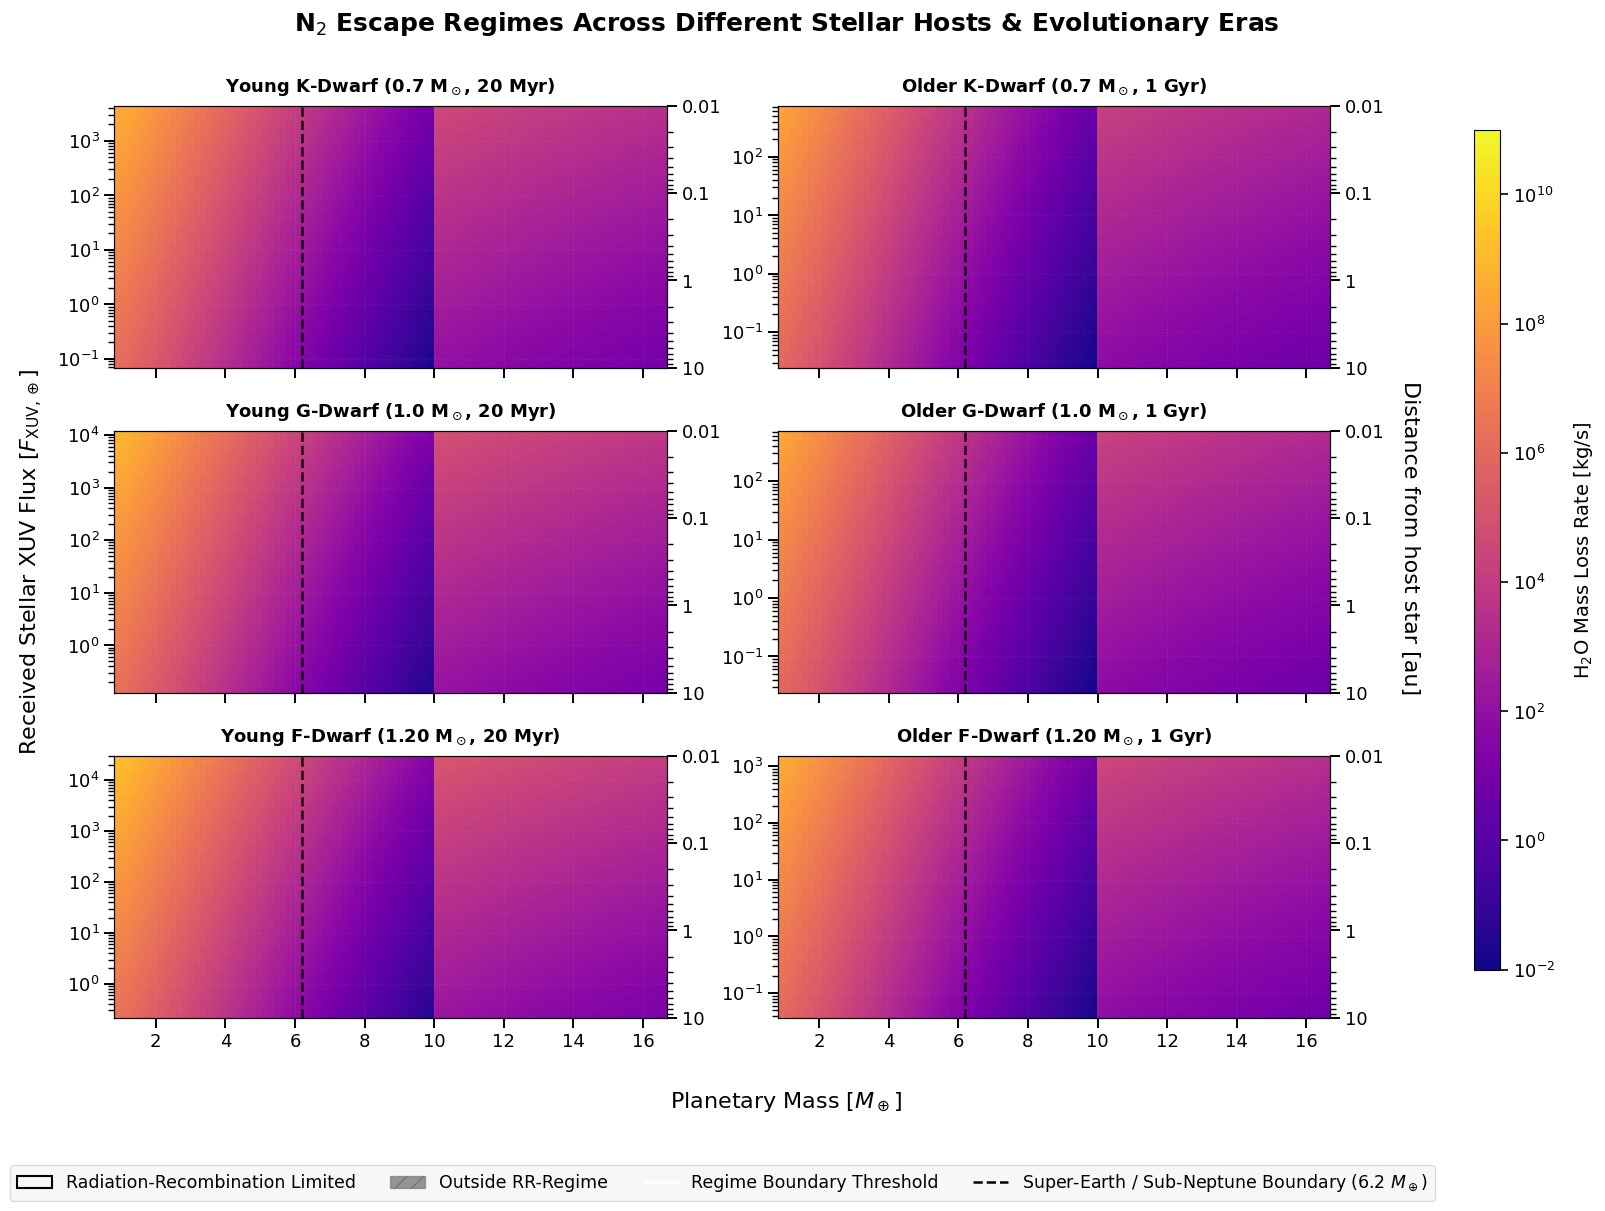

In [75]:
# 2. RENDER THE GRAPHICS
fig, axes = plt.subplots(3, 2, figsize=(16, 12), sharex=True, sharey=False)
axes = axes.flatten()
last_pcm = None  

for i, data in enumerate(computed_data_CO2):
    ax = axes[i]
    
    # -----------------------------------------------------------------------------------------
    # FIX 1: Set the log scale FIRST so that contours interpolate in log-space
    # -----------------------------------------------------------------------------------------
    ax.set_yscale('log')
    ax.set_ylim(data['fluxes_plot'].min(), data['fluxes_plot'].max())
    
    # Plot the underlying mass loss rate data
    pcm = ax.pcolormesh(data['X'], data['Y'], data['Z_mdot'], 
                        norm=colors.LogNorm(vmin=1e-2, vmax=1e11), 
                        cmap='plasma', shading='auto')
    last_pcm = pcm  
    
    # Underlay the regime masks (Now perfectly aligned)
    ax.contourf(data['X'], data['Y'], data['Z_mask'], hatches=['//'], levels=[-0.1, 0.5], colors='black', alpha=0.4, zorder=2) 
    ax.contour(data['X'], data['Y'], data['Z_mask'], levels=[0.5], colors='white', linewidths=2.5, zorder=2)
    
    # -----------------------------------------------------------------------------------------
    # RESTORED: Demographic boundary line
    # -----------------------------------------------------------------------------------------
    ax.axvline(6.2, color='black', linestyle='--', linewidth=1.8, alpha=0.85, zorder=3)
    
    # Formatting left (Primary Flux) Y-axis
    ax.set_title(data['case']['label'], fontsize=13, weight='bold', pad=10)
    ax.grid(True, alpha=0.15, linestyle=':')
    
    ax.tick_params(axis='both', which='major', labelsize=13, length=7, width=1.4)
    ax.tick_params(axis='both', which='minor', labelsize=10, length=4, width=1.0)
    
    # -----------------------------------------------------------------------------------------
    # RIGHT SIDE SECONDARY AXIS (Distance Mapping)
    # -----------------------------------------------------------------------------------------
    ax_right = ax.twinx()
    ax_right.set_yscale('log')
    dist_min = semi_major_axis.min() / au
    dist_max = semi_major_axis.max() / au
    ax_right.set_ylim(dist_max, dist_min)
    
    ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
    ax_right.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax_right.tick_params(axis='y', which='major', labelsize=13, length=7, width=1.4)
    ax_right.tick_params(axis='y', which='minor', length=4, width=1.0)

### Global Layout Formatting ##################################################################################################################################################################
active_patch = patches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, label='Radiation-Recombination Limited')

# FIXED: Changed edgecolor from 'none' to a visible color so the hatch pattern can render in the legend
shaded_patch = patches.Patch(facecolor='black', alpha=0.4, hatch='//', edgecolor='#444444', label='Outside RR-Regime')
boundary_line = Line2D([0], [0], color='white', linewidth=2.5, linestyle='-', label='Regime Boundary Threshold')

# RESTORED: Demarcation line tracking handle
demarcation_line = Line2D([0], [0], color='black', linewidth=1.8, linestyle='--', label='Super-Earth / Sub-Neptune Boundary ($6.2\ M_\oplus$)')

# Expanded handle list and bumped ncol up to 4 to center smoothly below the subplots
fig.legend(handles=[active_patch, shaded_patch, boundary_line, demarcation_line], 
           loc='lower center', bbox_to_anchor=(0.46, -0.04), 
           ncol=4, fontsize=12.5, frameon=True, facecolor='#f5f5f5', edgecolor='#d3d3d3') 

# Adjust geometry padding margins: 
plt.subplots_adjust(left=0.08, right=0.84, hspace=0.24, wspace=0.20, bottom=0.12)

# Global Text Tags
fig.suptitle('N$_2$ Escape Regimes Across Different Stellar Hosts & Evolutionary Eras', fontsize=18, y=0.96, weight='bold')
fig.supxlabel(r'Planetary Mass $[M_\oplus]$', fontsize=16, y=0.04)
fig.supylabel(r'Received Stellar XUV Flux $[F_{\mathrm{XUV},\oplus}]$', fontsize=16, x=0.02)

# Global secondary title on the right flank
fig.text(0.89, 0.52, 'Distance from host star [au]', fontsize=16, rotation=-90, va='center', ha='center')

# Anchor the global colorbar matching our hardcoded vmin/vmax limits
cbar_ax = fig.add_axes([0.93, 0.16, 0.016, 0.70])
cbar = fig.colorbar(last_pcm, cax=cbar_ax)
cbar.set_label(r'H$_2$O Mass Loss Rate $[\mathrm{kg/s}]$', fontsize=14, labelpad=12)
cbar_ax.tick_params(axis='y', which='major', labelsize=13, length=6, width=1.2)

plt.show()

In [112]:
### Check how the regime break migrates for H2 dominated atmosphere ###
# planet variables
semi_major_axis = np.logspace(-2, 1, 120) * au # Distance from 0.01 to 10 AU
masses_2D = np.linspace(0.5, 30, 90) * M_earth  # Planet mass from 0.5 to 30 M_earth

n_masses = len(masses_2D)
n_distances = len(semi_major_axis)

# Define the 4 distinct host star cases to populate the subplots
stellar_cases = [
    {'M_star': 0.5,  'age': 7.0 * 10**6, 'label': 'Young K-Dwarf (0.5 M$_\odot$, 7 Myr)'},
    {'M_star': 0.5,  'age': 1.0 * 10**9, 'label': 'Older K-Dwarf (0.5 M$_\odot$, 1 Gyr)'},
    {'M_star': 1.0,  'age': 7.0 * 10**6, 'label': 'Young G-Dwarf (1.0 M$_\odot$, 7 Myr)'},
    {'M_star': 1.0,  'age': 1.0 * 10**9, 'label': 'Older G-Dwarf (1.0 M$_\odot$, 1 Gyr)'},
    {'M_star': 1.20,  'age': 7.0 * 10**6, 'label': 'Young F-Dwarf (1.20 M$_\odot$, 7 Myr)'},
    {'M_star': 1.20,  'age': 1.0 * 10**9, 'label': 'Older F-Dwarf (1.20 M$_\odot$, 1 Gyr)'}
]

# Isolate the microphysics strictly for water
h2_specs = species_microphysics['H2']

masses_plot = masses_2D / M_earth
computed_data = []  # To store results for each case

for case in stellar_cases:
    M_s = case['M_star'] * solar_mass
    age_s = case['age']
    F_bol_array, F_xuv_array = get_escape_fluxes(M_s, age_s, semi_major_axis)
    
    fluxes_plot = F_xuv_array / F_earth_xuv
    X, Y = np.meshgrid(masses_plot, fluxes_plot)
    
    # Run the computational grid
    atms_varied_2D = np.array([[make_simple_atmosphere(
        M_p=M, determine_radius=True, F_xuv=F_xuv,
        mu_photo=h2_specs['mu_photo'],
        P_0=2000, T_wind=10**4,
        T_eq=Atmosphere.determine_temperature_from_bolometric_flux(F_bol=F_b),
        resolution=3000, dominant_species='H2'
    ) for F_xuv, F_b in zip(F_xuv_array, F_bol_array)] for M in masses_2D])

    # Flatten and sweep
    atms_varied_flat = atms_varied_2D.flatten()
    M_dot_flat, regime_break, rr_mask_flat = sweep_parameter(atms_varied_flat)

    Z_mdot = np.array(M_dot_flat).reshape((n_masses, n_distances)).T
    Z_mask = np.array(rr_mask_flat).reshape((n_masses, n_distances)).T.astype(float)
    
    # Store the results for plotting
    computed_data.append({
        'case': case, 'X': X, 'Y': Y, 
        'Z_mdot': Z_mdot, 'Z_mask': Z_mask, 
        'fluxes_plot': fluxes_plot
    })



<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:16: SyntaxWarning: invalid escape sequence '\o'
<>:11: SyntaxWarning: invalid escape sequence '\o'
<>:12: SyntaxWarning: invalid escape sequence '\o'
<>:13: SyntaxWarning: invalid escape sequence '\o'
<>:14: SyntaxWarning: invalid escape sequence '\o'
<>:15: SyntaxWarning: invalid escape sequence '\o'
<>:16: SyntaxWarning: invalid escape sequence '\o'
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\2428985859.py:11: SyntaxWarning: invalid escape sequence '\o'
  {'M_star': 0.5,  'age': 7.0 * 10**6, 'label': 'Young K-Dwarf (0.5 M$_\odot$, 7 Myr)'},
C:\Users\malin\AppData\Local\Temp\ipykernel_8684\2428985859.py:12: SyntaxWarning: invalid escape sequence '\o'
  {'M_star': 0.5,  'age': 1.0 * 10**9, 'label': 'Older K-Dwarf (0.5 M$_\odot$

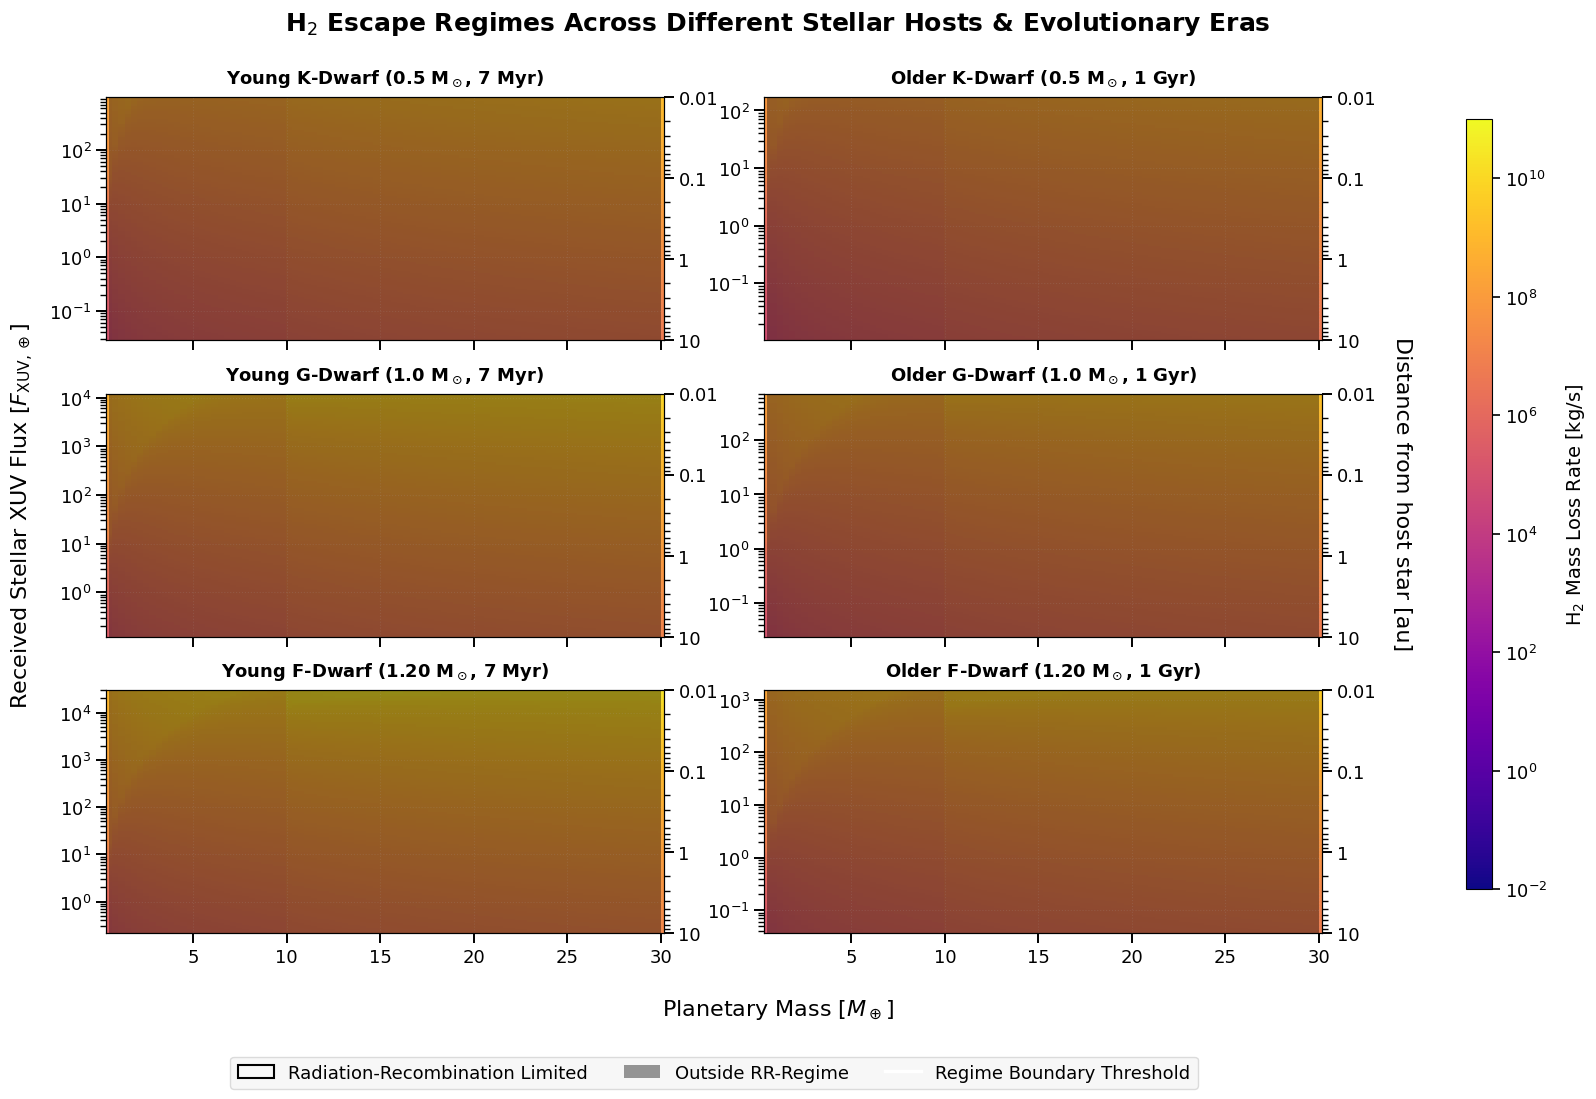

In [ ]:
# 2. RENDER THE GRAPHICS
fig, axes = plt.subplots(3, 2, figsize=(16, 11), sharex=True, sharey=False)
axes = axes.flatten()
last_pcm = None  

for i, data in enumerate(computed_data):
    ax = axes[i]
    
    pcm = ax.pcolormesh(data['X'], data['Y'], data['Z_mdot'], 
                        norm=colors.LogNorm(vmin=1e-2, vmax=1e11), 
                        cmap='plasma', shading='auto')
    last_pcm = pcm  
    
    # Underlay the regime masks
    ax.contourf(data['X'], data['Y'], data['Z_mask'], levels=[-0.5, 0.5], colors='black', alpha=0.4) 
    ax.contour(data['X'], data['Y'], data['Z_mask'], levels=[0.5], colors='white', linewidths=2.5)
    
    # Formatting left (Primary Flux) Y-axis
    ax.set_title(data['case']['label'], fontsize=13, weight='bold', pad=10)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.15, linestyle=':')
    ax.set_ylim(data['fluxes_plot'].min(), data['fluxes_plot'].max())
    
    ax.tick_params(axis='both', which='major', labelsize=13, length=7, width=1.4)
    ax.tick_params(axis='both', which='minor', labelsize=10, length=4, width=1.0)
    
    # -----------------------------------------------------------------------------------------
    # RIGHT SIDE SECONDARY AXIS (Distance Mapping)
    # -----------------------------------------------------------------------------------------
    ax_right = ax.twinx()
    ax_right.set_yscale('log')
    dist_min = semi_major_axis.min() / au
    dist_max = semi_major_axis.max() / au
    ax_right.set_ylim(dist_max, dist_min)
    
    # FIX: Remove the conditional formatting block to force distance values on ALL subplots
    ax_right.yaxis.set_major_formatter(ticker.FormatStrFormatter('%g'))
    ax_right.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax_right.tick_params(axis='y', which='major', labelsize=13, length=7, width=1.4)
    ax_right.tick_params(axis='y', which='minor', length=4, width=1.0)

### Global Layout Formatting ##################################################################################################################################################################
active_patch = patches.Patch(facecolor='none', edgecolor='black', linewidth=1.5, label='Radiation-Recombination Limited')
shaded_patch = patches.Patch(facecolor='black', alpha=0.4, edgecolor='none', label='Outside RR-Regime')
boundary_line = Line2D([0], [0], color='white', linewidth=2.5, linestyle='-', label='Regime Boundary Threshold')

fig.legend(handles=[active_patch, shaded_patch, boundary_line], 
           loc='lower center', bbox_to_anchor=(0.46, -0.03), 
           ncol=3, fontsize=13, frameon=True, facecolor='#f5f5f5', edgecolor='#d3d3d3') 

# Adjust geometry padding margins: 
# Note: wspace increased slightly from 0.12 to 0.18 to ensure the new ticks don't overlap with the labels next to them.
plt.subplots_adjust(left=0.08, right=0.84, hspace=0.22, wspace=0.18, bottom=0.12)

# Global Text Tags
fig.suptitle('H$_2$ Escape Regimes Across Different Stellar Hosts & Evolutionary Eras', fontsize=18, y=0.96, weight='bold')
fig.supxlabel(r'Planetary Mass $[M_\oplus]$', fontsize=16, y=0.04)
fig.supylabel(r'Received Stellar XUV Flux $[F_{\mathrm{XUV},\oplus}]$', fontsize=16, x=0.02)

# Global secondary title on the right flank
fig.text(0.89, 0.52, 'Distance from host star [au]', fontsize=16, rotation=-90, va='center', ha='center')

# Anchor the global colorbar matching our hardcoded vmin/vmax limits
cbar_ax = fig.add_axes([0.93, 0.16, 0.016, 0.70])
cbar = fig.colorbar(last_pcm, cax=cbar_ax)
cbar.set_label(r'H$_2$ Mass Loss Rate $[\mathrm{kg/s}]$', fontsize=14, labelpad=12)
cbar_ax.tick_params(axis='y', which='major', labelsize=13, length=6, width=1.2)

plt.show()